# Bibliotecas Necessarias

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import kruskal
from scipy.stats import friedmanchisquare, wilcoxon
import operator
import matplotlib
import math
import networkx
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder
import warnings
from scipy.stats import shapiro
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.model_selection import KFold
import time
from sklearn import preprocessing
from pymfe.mfe import MFE
import joblib  # para salvar resultados em arquivo binário
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
import re
from sklearn.model_selection import train_test_split

# Processo de anonimização para todos os bancos

In [ ]:
# Definir a semente para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Função para processar o dataset e identificar colunas categóricas
def process_dataset(file_path):
    """Processa um dataset para extrair colunas e identificar categorias."""
    # Carregar o dataset
    df = pd.read_excel(file_path)

    # Remover espaços extras dos nomes das colunas
    df.columns = df.columns.str.strip()

    # Criar a tupla de nomes das colunas
    names = tuple(df.columns)

    # Converter 'Country' para string para evitar erros de detecção
    if 'Country' in df.columns:
        df['Country'] = df['Country'].astype(str)

    # Identificar colunas categóricas pelo tipo de dado
    categorical = set(df.select_dtypes(include=['object', 'category']).columns)

    # Incluir colunas numéricas que possuem menos de 20 valores únicos
    possible_categorical = set(df.columns[df.nunique() < 20])
    categorical.update(possible_categorical)

    return {"names": names, "categorical": categorical, "df": df}

# Função para calcular os spans das colunas
def get_spans(df, partition, scale=None):
    spans = {}
    for column in df.columns:
        if column in categorical:
            span = len(df[column][partition].unique())
        else:
            span = df[column][partition].max() - df[column][partition].min()
        if scale is not None:
            span = span / scale[column]
        spans[column] = span
    return spans

# Função para dividir uma partição
def split(df, partition, column):
    dfp = df[column][partition]
    if column in categorical:
        values = dfp.unique()
        lv = set(values[:len(values) // 2])
        rv = set(values[len(values) // 2:])
        return dfp.index[dfp.isin(lv)], dfp.index[dfp.isin(rv)]
    else:
        median = dfp.median()
        dfl = dfp.index[dfp < median]
        dfr = dfp.index[dfp >= median]
        return (dfl, dfr)

# Função para verificar k-anonymity
def is_k_anonymous(df, partition, sensitive_column, k=3):
    if len(partition) < k:
        return False
    return True

# Função para calcular a diversidade
def diversity(df, partition, column):
    return len(df[column][partition].unique())

# Função para verificar l-diversity
def is_l_diverse(df, partition, sensitive_column, l=2):
    return diversity(df, partition, sensitive_column) >= l

# Função para calcular t-closeness
def t_closeness(df, partition, column, global_freqs):
    total_count = float(len(partition))
    d_max = None
    group_counts = df.loc[partition].groupby(column, observed=False)[column].agg('count')
    for value, count in group_counts.to_dict().items():
        p = count / total_count
        d = abs(p - global_freqs[value])
        if d_max is None or d > d_max:
            d_max = d
    return d_max

# Função para verificar t-closeness
def is_t_close(df, partition, sensitive_column, global_freqs, p=0.2):
    if not sensitive_column in categorical:
        raise ValueError("this method only works for categorical values")
    return t_closeness(df, partition, sensitive_column, global_freqs) <= p

# Função para particionar o dataset
def partition_dataset(df, feature_columns, sensitive_column, scale, is_valid):
    finished_partitions = []
    partitions = [df.index]
    while partitions:
        partition = partitions.pop(0)
        spans = get_spans(df[feature_columns], partition, scale)
        for column, span in sorted(spans.items(), key=lambda x: -x[1]):
            lp, rp = split(df, partition, column)
            if not is_valid(df, lp, sensitive_column) or not is_valid(df, rp, sensitive_column):
                continue
            partitions.extend((lp, rp))
            break
        else:
            finished_partitions.append(partition)
    return finished_partitions

# Função para construir índices
def build_indexes(df):
    indexes = {}
    for column in categorical:
        values = sorted(df[column].unique())
        indexes[column] = {x: y for x, y in zip(values, range(len(values)))}
    return indexes

# Função para obter coordenadas
def get_coords(df, column, partition, indexes, offset=0.1):
    if column in categorical:
        sv = df[column][partition].sort_values()
        l, r = indexes[column][sv[sv.index[0]]], indexes[column][sv[sv.index[-1]]] + 1.0
    else:
        sv = df[column][partition].sort_values()
        next_value = sv[sv.index[-1]]
        larger_values = df[df[column] > next_value][column]
        if len(larger_values) > 0:
            next_value = larger_values.min()
        l = sv[sv.index[0]]
        r = next_value
    l -= offset
    r += offset
    return l, r

# Função para obter retângulos de partição
def get_partition_rects(df, partitions, column_x, column_y, indexes, offsets=[0.1, 0.1]):
    rects = []
    for partition in partitions:
        xl, xr = get_coords(df, column_x, partition, indexes, offset=offsets[0])
        yl, yr = get_coords(df, column_y, partition, indexes, offset=offsets[1])
        rects.append(((xl, yl), (xr, yr)))
    return rects

# Função para obter limites
def get_bounds(df, column, indexes, offset=1.0):
    if column in categorical:
        return 0 - offset, len(indexes[column]) + offset
    return df[column].min() - offset, df[column].max() + offset

# Função para plotar retângulos
def plot_rects(df, ax, rects, column_x, column_y, edgecolor='black', facecolor='none'):
    for (xl, yl), (xr, yr) in rects:
        ax.add_patch(patches.Rectangle((xl, yl), xr - xl, yr - yl, linewidth=1, edgecolor=edgecolor, facecolor=facecolor, alpha=0.5))
    ax.set_xlim(*get_bounds(df, column_x, indexes))
    ax.set_ylim(*get_bounds(df, column_y, indexes))
    ax.set_xlabel(column_x)
    ax.set_ylabel(column_y)

# Função para agregar colunas categóricas
def agg_categorical_column(series):
    unique_values = set(series.astype(str))
    return f"[{', '.join(sorted(unique_values))}]"

# Função para agregar colunas numéricas
def agg_numerical_column(series):
    mean_val = series.mean()
    return mean_val

# Função para construir o dataset anonimizado
def build_anonymized_dataset(df, partitions, feature_columns, sensitive_column, max_partitions=None):
    rows = []
    for i, partition in enumerate(partitions):
        if i % 100 == 1:
            print("Finished {} partitions...".format(i))
        if max_partitions is not None and i > max_partitions:
            break
        partition_df = df.loc[partition]
        grouped_columns = {}
        for column in feature_columns:
            if column in categorical:
                grouped_columns[column] = partition_df[column].agg(agg_categorical_column)
            else:
                grouped_columns[column] = partition_df[column].agg(agg_numerical_column)
        sensitive_counts = partition_df.groupby(sensitive_column, observed=False).size()
        for sensitive_value, count in sensitive_counts.items():
            if count == 0:
                continue
            values = grouped_columns.copy()
            values.update({
                sensitive_column: sensitive_value,
                'count': count,
            })
            rows.append(values)
    return pd.DataFrame(rows)

# Função para adicionar ruído diferencial a valores binários
def process_value(value, p, k):
    """
    Adiciona ruído diferencial à variável binária.
    :param value: O valor binário original (0 ou 1)
    :param p: Probabilidade de retornar um valor aleatório
    :param k: Probabilidade de retornar 1 no valor aleatório
    :returns: Valor com privacidade diferencial aplicada
    """
    rv = random.random()
    if rv <= p:
        rv = random.random()
        if rv <= k:
            return 0
        return 1
    else:
        return value

# Função para adicionar ruído laplaciano a valores numéricos
def add_laplace_noise(value, epsilon, sensitivity=1):
    """
    Adiciona ruído laplaciano a um valor numérico.
    :param value: Valor original da variável numérica
    :param epsilon: O parâmetro de privacidade (quanto menor, mais privacidade)
    :param sensitivity: A sensibilidade da função, normalmente é 1
    :return: O valor com ruído adicionado
    """
    noise = np.random.laplace(0, sensitivity / epsilon)
    return value + noise

# Função para aplicar Differential Privacy ao dataset
def apply_differential_privacy(df, categorical, epsilon=0.5, p=0.5, k=0.5):
    """
    Aplica Differential Privacy ao dataset.
    :param df: O dataframe original
    :param categorical: Conjunto de colunas categóricas
    :param epsilon: Parâmetro de privacidade para ruído laplaciano
    :param p: Probabilidade de retornar um valor aleatório (para variáveis binárias)
    :param k: Probabilidade de retornar 1 no valor aleatório (para variáveis binárias)
    :return: Dataframe com Differential Privacy aplicado
    """
    df_dp = df.copy()
    
    # Aplicar ruído laplaciano a colunas numéricas
    for column in df.columns:
        if column not in categorical:  # Colunas numéricas
            df_dp[column + "_anonymized"] = df[column].apply(lambda x: add_laplace_noise(x, epsilon))
    
    # Aplicar ruído diferencial a colunas categóricas
    for column in categorical:  # Colunas categóricas
        values = []
        for x in df[column]:
            values.append(process_value(x, p, k))
        df_dp[column + "_dp"] = np.array(values)
    
    return df_dp

# Função para classificar colunas categóricas em Label Encoding ou One-Hot Encoding com base no dataset original
def classificar_colunas_categoricas(df_original, colunas_categoricas):
    """Classifica colunas categóricas em Label Encoding ou One-Hot Encoding com base no dataset original."""
    colunas_label = []
    colunas_one_hot = []
    
    for coluna in colunas_categoricas:
        # Verificar se a coluna tem 5 ou menos valores únicos
        if df_original[coluna].nunique() <= 5:
            colunas_label.append(coluna)
        else:
            colunas_one_hot.append(coluna)
    
    return colunas_label, colunas_one_hot

# Função para aplicar Label Encoding e One-Hot Encoding ao dataset anonimizado
def aplicar_codificacao(df_anonimizado, colunas_label, colunas_one_hot):
    """Aplica Label Encoding e One-Hot Encoding ao DataFrame anonimizado."""
    # Aplicar Label Encoding
    label_encoder = LabelEncoder()
    for coluna in colunas_label:
        if coluna in df_anonimizado.columns:  # Verificar se a coluna existe no dataset anonimizado
            df_anonimizado[coluna] = label_encoder.fit_transform(df_anonimizado[coluna].astype(str))
    
    # Aplicar One-Hot Encoding com valores 0 e 1
    for coluna in colunas_one_hot:
        if coluna in df_anonimizado.columns:  # Verificar se a coluna existe no dataset anonimizado
            df_anonimizado = pd.get_dummies(df_anonimizado, columns=[coluna], dtype=int)
    
    return df_anonimizado

# Definir o diretório onde os arquivos estão armazenados
diretorio = "./Datasets"

# Listar todos os arquivos .xlsx no diretório
file_paths = [os.path.join(diretorio, arquivo) for arquivo in os.listdir(diretorio) if arquivo.endswith(".xlsx")]

# Dicionário para armazenar os resultados
results = {}

# Processar cada banco de dados
for file_path in file_paths:
    print(f"Processando {file_path}...")
    result = process_dataset(file_path)
    df = result["df"]
    categorical = result["categorical"]  # Colunas categóricas identificadas no dataset original
    feature_columns = [col for col in df.columns if col != 'Label']
    sensitive_column = 'Label'
    
    # Classificar colunas categóricas com base no dataset original
    colunas_label, colunas_one_hot = classificar_colunas_categoricas(df, categorical)
    
    # Calcular frequências globais para T-closeness
    total_count = float(len(df))
    group_counts = df.groupby(sensitive_column)[sensitive_column].agg('count')
    global_freqs = {value: count / total_count for value, count in group_counts.to_dict().items()}
    
    full_spans = get_spans(df, df.index)
    
    # Anonimização com k-anonymity
    finished_k_anonymous_partitions = partition_dataset(df, feature_columns, sensitive_column, full_spans, is_k_anonymous)
    dfn_k = build_anonymized_dataset(df, finished_k_anonymous_partitions, feature_columns, sensitive_column)
    
    # Salvar o dataset anonimizado com k-anonymity (sem codificação)
    output_path_k_anonimizado = file_path.replace(".xlsx", "_k_anonimizado.xlsx")
    dfn_k.to_excel(output_path_k_anonimizado, index=False)
    print(f"Dataset anonimizado com k-anonymity salvo em {output_path_k_anonimizado}")
    
    # Aplicar Label Encoding e One-Hot Encoding ao dataset anonimizado com k-anonymity
    dfn_k_codificado = aplicar_codificacao(dfn_k.copy(), colunas_label, colunas_one_hot)
    output_path_k_codificado = file_path.replace(".xlsx", "_k_anonimizado_codificado.xlsx")
    dfn_k_codificado.to_excel(output_path_k_codificado, index=False)
    print(f"Dataset anonimizado com k-anonymity e codificado salvo em {output_path_k_codificado}")
    
    # Anonimização com l-diversity
    finished_l_diverse_partitions = partition_dataset(df, feature_columns, sensitive_column, full_spans, lambda *args: is_k_anonymous(*args) and is_l_diverse(*args))
    dfn_l = build_anonymized_dataset(df, finished_l_diverse_partitions, feature_columns, sensitive_column)
    
    # Salvar o dataset anonimizado com l-diversity (sem codificação)
    output_path_l_anonimizado = file_path.replace(".xlsx", "_l_diverso.xlsx")
    dfn_l.to_excel(output_path_l_anonimizado, index=False)
    print(f"Dataset anonimizado com l-diversity salvo em {output_path_l_anonimizado}")
    
    # Aplicar Label Encoding e One-Hot Encoding ao dataset anonimizado com l-diversity
    dfn_l_codificado = aplicar_codificacao(dfn_l.copy(), colunas_label, colunas_one_hot)
    output_path_l_codificado = file_path.replace(".xlsx", "_l_diverso_codificado.xlsx")
    dfn_l_codificado.to_excel(output_path_l_codificado, index=False)
    print(f"Dataset anonimizado com l-diversity e codificado salvo em {output_path_l_codificado}")
    
    # Anonimização com T-closeness
    finished_t_close_partitions = partition_dataset(df, feature_columns, sensitive_column, full_spans, lambda *args: is_k_anonymous(*args) and is_t_close(*args, global_freqs))
    dfn_t = build_anonymized_dataset(df, finished_t_close_partitions, feature_columns, sensitive_column)
    
    # Salvar o dataset anonimizado com T-closeness (sem codificação)
    output_path_t_anonimizado = file_path.replace(".xlsx", "_t_close.xlsx")
    dfn_t.to_excel(output_path_t_anonimizado, index=False)
    print(f"Dataset anonimizado com T-closeness salvo em {output_path_t_anonimizado}")
    
    # Aplicar Label Encoding e One-Hot Encoding ao dataset anonimizado com T-closeness
    dfn_t_codificado = aplicar_codificacao(dfn_t.copy(), colunas_label, colunas_one_hot)
    output_path_t_codificado = file_path.replace(".xlsx", "_t_close_codificado.xlsx")
    dfn_t_codificado.to_excel(output_path_t_codificado, index=False)
    print(f"Dataset anonimizado com T-closeness e codificado salvo em {output_path_t_codificado}")
    
    # Anonimização com Differential Privacy
    dfn_dp = apply_differential_privacy(df, categorical)
    
    # Salvar o dataset anonimizado com Differential Privacy (sem codificação)
    output_path_dp = file_path.replace(".xlsx", "_dp.xlsx")
    dfn_dp.to_excel(output_path_dp, index=False)
    print(f"Dataset anonimizado com Differential Privacy salvo em {output_path_dp}")

print("Processamento concluído!")

# Processo de avaliação com as premissas para todos os bancos anonimizados

In [ ]:
warnings.filterwarnings('ignore', category=FutureWarning)

# ======================
# Parâmetros globais
# ======================
K = 3
L = 2
LABEL = "Label"

# ======================
# Funções auxiliares
# ======================

def normalizar_nomes_colunas_para_comparacao(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.replace('_anonymized', '', regex=False)
        .str.replace('_codificado', '', regex=False)
    )
    return df


def expand_lists(df, quasi_identifiers):
    df = df.copy()
    for col in quasi_identifiers:
        df[col] = df[col].apply(
            lambda x: tuple(sorted(x)) if isinstance(x, list) else x
        )
    return df


def verificar_k_anonimato(df, quasi_identifiers, k):
    df = expand_lists(df, quasi_identifiers)
    if 'count' in df.columns:
        grupos = df.groupby(quasi_identifiers)['count'].sum().reset_index()
    else:
        grupos = df.groupby(quasi_identifiers).size().reset_index(name='count')
    return grupos['count'].min() >= k, grupos['count'].min()


def verificar_l_diversidade(df, quasi_identifiers, sensitive_attribute, l):
    df = expand_lists(df, quasi_identifiers)
    diversidade = (
        df.groupby(quasi_identifiers)[sensitive_attribute]
        .nunique()
        .reset_index(name='diversidade')
    )
    return diversidade['diversidade'].min() >= l, diversidade['diversidade'].min()


def calcular_ncp(df_original, df_anon, quasi_identifiers):
    ncp_total = 0
    cols_validas = 0

    for col in quasi_identifiers:
        try:
            # Numérico
            try:
                orig_num = pd.to_numeric(df_original[col], errors='raise')
                anon_num = pd.to_numeric(df_anon[col], errors='raise')

                range_orig = orig_num.max() - orig_num.min()
                range_anon = anon_num.max() - anon_num.min()

                ncp_col = 0 if range_orig == 0 else max(
                    0, (range_anon - range_orig) / range_orig
                )
            except:
                # Categórico
                unique_orig = df_original[col].nunique()
                unique_anon = df_anon[col].nunique()

                ncp_col = 0 if unique_orig <= 1 else max(
                    0, (unique_orig - unique_anon) / unique_orig
                )

            ncp_total += ncp_col
            cols_validas += 1

        except:
            pass

    return round(ncp_total / cols_validas, 4) if cols_validas > 0 else 0


def verificar_similaridade(df_original, df_anon, quasi_identifiers):
    try:
        df_orig = df_original[quasi_identifiers].astype(str).fillna('')
        df_anon = df_anon[quasi_identifiers].astype(str).fillna('')

        encoder = OneHotEncoder(handle_unknown='ignore')
        orig_encoded = encoder.fit_transform(df_orig)
        anon_encoded = encoder.transform(df_anon)

        sim_matrix = cosine_similarity(orig_encoded, anon_encoded)
        max_sim = np.max(sim_matrix, axis=1)

        return round(np.mean(max_sim), 4)
    except:
        return None


def avaliar_ncp(ncp):
    if ncp < 0.3:
        return "Baixa perda"
    elif ncp < 0.6:
        return "Perda moderada"
    else:
        return "Alta perda"


def avaliar_similaridade(sim):
    if sim is None:
        return ""
    if sim < 0.3:
        return "Baixo risco"
    elif sim < 0.6:
        return "Risco moderado"
    else:
        return "Alto risco"


def extrair_nome_base(nome):
    nome = nome.lower().replace('.xlsx', '')
    for s in ['_dp', '_k_anonimizado', '_l_diverso', '_t_close', '_codificado']:
        nome = nome.replace(s, '')
    return nome


# ======================
# Pipeline principal
# ======================

def processar_bancos(diretorio):
    resultados = []

    arquivos = [
        f for f in os.listdir(diretorio)
        if f.endswith('.xlsx') and not f.startswith('~$')
    ]

    bancos_originais = {}

    # Carregar originais
    for arquivo in arquivos:
        if all(s not in arquivo.lower() for s in
               ['_dp', '_k_anonimizado', '_l_diverso', '_t_close', '_codificado']):
            try:
                df = pd.read_excel(os.path.join(diretorio, arquivo))
                bancos_originais[extrair_nome_base(arquivo)] = df.copy()
            except:
                pass

    # Processar anonimizados
    for arquivo in arquivos:
        if all(s not in arquivo.lower() for s in
               ['_dp', '_k_anonimizado', '_l_diverso', '_t_close', '_codificado']):
            continue

        caminho = os.path.join(diretorio, arquivo)

        try:
            df = pd.read_excel(caminho)
        except:
            continue

        print(f"\nProcessando: {arquivo}")

        nome_base = extrair_nome_base(arquivo)
        df_original = bancos_originais.get(nome_base)

        if df_original is None:
            continue

        tecnica = (
            'DP' if '_dp' in arquivo.lower() else
            'K-Anonimato' if '_k_anonimizado' in arquivo.lower() else
            'L-Diversidade' if '_l_diverso' in arquivo.lower() else
            'T-Closeness' if '_t_close' in arquivo.lower() else
            'Codificação'
        )

        # ---------- NCP ----------
        if tecnica == 'DP':
            df_ncp = normalizar_nomes_colunas_para_comparacao(df)
            quasi_ncp = [
                c for c in df_original.columns
                if c in df_ncp.columns and c not in [LABEL, 'count']
            ]
        else:
            df_ncp = df
            quasi_ncp = [
                c for c in df_original.columns
                if c in df.columns and c not in [LABEL, 'count']
            ]

        ncp = calcular_ncp(df_original, df_ncp, quasi_ncp)

        # ---------- Similaridade ----------
        if tecnica == 'DP':
            similaridade = None
            avaliacao_sim = "Não aplicável (DP)"
        else:
            similaridade = verificar_similaridade(df_original, df, quasi_ncp)
            avaliacao_sim = avaliar_similaridade(similaridade)

        # ---------- k / l ----------
        k_ok, k_min = (verificar_k_anonimato(df, quasi_ncp, K)
                       if tecnica == 'K-Anonimato' else (None, None))

        l_ok, l_min = (verificar_l_diversidade(df, quasi_ncp, LABEL, L)
                       if tecnica == 'L-Diversidade' else (None, None))

        resultados.append({
            'Banco': arquivo,
            'Técnica': tecnica,
            'k-anonimato': "OK" if k_ok else "",
            'k mínimo': k_min or "",
            'l-diversidade': "OK" if l_ok else "",
            'l mínimo': l_min or "",
            'NCP': ncp,
            'Avaliação NCP': avaliar_ncp(ncp),
            'Similaridade': similaridade if similaridade is not None else "",
            'Avaliação Similaridade': avaliacao_sim
        })

    df_res = pd.DataFrame(resultados)
    out = os.path.join(diretorio, 'resultados_premissas.csv')
    df_res.to_csv(out, index=False, encoding='utf-8-sig')

    print(f"\n✅ Finalizado. Resultados salvos em: {out}")


# ======================
# Executar
# ======================

diretorio = (
    ".Dataset Finalizados Anonimzados antes da codificacao"
)

processar_bancos(diretorio)

# Processo de avaliação com as metricas para todos os bancos

In [ ]:
# Função para avaliar modelos
def avaliar_modelos(X_train, y_train, X_test, y_test):
    # Dicionário para armazenar resultados
    resultados = {}

    # Lista de modelos
    modelos = {
        'DecisionTree': DecisionTreeClassifier(random_state=42),
        'RandomForest': RandomForestClassifier(random_state=42, n_estimators=100),
        'SVM': SVC(kernel='linear', random_state=42),
        'NaiveBayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_neighbors=5)
    }

    # Ajustar o StandardScaler no conjunto de treinamento do fold atual
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)  # Ajusta e transforma os dados de treinamento
    X_test_scaled = scaler.transform(X_test)       # Apenas transforma os dados de teste

    # Iterar sobre os modelos
    for nome, modelo in modelos.items():
        if nome == 'SVM':
            # Usar os dados já escalados
            modelo.fit(X_train_scaled, y_train)
            y_pred_train = modelo.predict(X_train_scaled)
            y_pred_test = modelo.predict(X_test_scaled)
        else:
            # Modelos que não precisam de escalonamento
            modelo.fit(X_train, y_train)
            y_pred_train = modelo.predict(X_train)
            y_pred_test = modelo.predict(X_test)

        # Calcular métricas no conjunto de treinamento
        resultados[f'{nome}_Acurácia_Treino'] = accuracy_score(y_train, y_pred_train)
        resultados[f'{nome}_Precision_Treino'] = precision_score(y_train, y_pred_train, average='weighted', zero_division=0)
        resultados[f'{nome}_Recall_Treino'] = recall_score(y_train, y_pred_train, average='weighted')
        resultados[f'{nome}_F1-score_Treino'] = f1_score(y_train, y_pred_train, average='weighted')

        # Calcular métricas no conjunto de teste
        resultados[f'{nome}_Acurácia_Teste'] = accuracy_score(y_test, y_pred_test)
        resultados[f'{nome}_Precision_Teste'] = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
        resultados[f'{nome}_Recall_Teste'] = recall_score(y_test, y_pred_test, average='weighted')
        resultados[f'{nome}_F1-score_Teste'] = f1_score(y_test, y_pred_test, average='weighted')

    return resultados

# Função para aplicar K-Fold e avaliar modelos
def processar_k_fold(df):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    resultados_k_fold = []

    for fold, (train_index, test_index) in enumerate(kf.split(df), 1):
        df_treino = df.iloc[train_index].reset_index(drop=True)
        df_teste = df.iloc[test_index].reset_index(drop=True)

        X_train = df_treino.drop(columns=['Label'])
        y_train = df_treino['Label']
        X_test = df_teste.drop(columns=['Label'])
        y_test = df_teste['Label']

        resultados_fold = avaliar_modelos(X_train, y_train, X_test, y_test)
        resultados_fold['Fold'] = fold
        resultados_k_fold.append(resultados_fold)

    # Calcular médias dos folds
    df_resultados_fold = pd.DataFrame(resultados_k_fold)
    medias = df_resultados_fold.drop(columns=['Fold']).mean()
    return medias.to_dict()

# Função principal para processar os bancos de dados
def processar_bancos(diretorio):
    resultados_finais = []

    # Listar todos os arquivos no diretório
    arquivos = [f for f in os.listdir(diretorio) if f.endswith('.xlsx')]

    # Iterar sobre os arquivos encontrados
    for arquivo in arquivos:
        print(f"Processando banco: {arquivo}")
        caminho = os.path.join(diretorio, arquivo)
        
        # Ler arquivo Excel
        df = pd.read_excel(caminho)

        # Determinar o tipo (original ou anonimizado)
        tipo = 'Original' if 'anonimizado' not in arquivo and 'codificado' not in arquivo and 'dp' not in arquivo else 'Anonimizado'

        # Processar K-Fold e avaliar modelos
        resultados_banco = {'Banco': arquivo, 'Tipo': tipo}
        resultados_banco.update(processar_k_fold(df))
        resultados_finais.append(resultados_banco)

    # Salvar resultados em um DataFrame
    df_resultados = pd.DataFrame(resultados_finais)
    df_resultados.to_csv(os.path.join(diretorio, 'resultados.csv'), index=False)
    print("Processamento concluído! Resultados salvos em 'resultados.csv'.")

# Executar o processamento para o diretório especificado
diretorio = ".Datasets"
processar_bancos(diretorio)

# Processo de avaliação da melhor técnica de anonimização

In [ ]:
# Caminho do arquivo
caminho_arquivo = r'./resultados_metricas/resultados.xlsx'

# Leitura e pré-processamento
df = pd.read_excel(caminho_arquivo)
df.columns = df.columns.str.replace('Ã¡', 'á')

# Extração da técnica
df['Tecnica'] = df['Banco'].apply(lambda x: (
    'Original' if 'Original' in x else
    'DP' if 'dp' in x else
    'K-Anonimidade' if 'k_anonimizado' in x else
    'L-Diversidade' if 'l_diverso' in x else
    'T-Closeness' if 't_close' in x else
    'Original'
))

# Seleção das colunas de métricas de teste
colunas_metrica = [col for col in df.columns if '_Teste' in col]

# Transformação para formato longo
df_long = df.melt(
    id_vars=['Banco', 'Tipo', 'Tecnica'],
    value_vars=colunas_metrica,
    var_name='Metrica_Modelo',
    value_name='Valor'
)

# Separação das colunas
df_long[['Modelo', 'Metrica', 'TipoResultado']] = df_long['Metrica_Modelo'].str.split('_', expand=True)
df_long = df_long[df_long['TipoResultado'] == 'Teste']

# Lista de métricas que serão avaliadas
metricas = ['F1-score', 'Acurácia', 'Precision', 'Recall']

# Dicionário para armazenar vencedores
vencedores_geral = []

# Remove o banco original da análise
# df_long_2 = df_long[df_long['Tecnica'] != 'Original']

df_long_2 = df_long


### Verificar se tem normalidade ou não nos resultados, para definir se eu vou usar ANOVA ou Kruskal-Wallis

In [ ]:
# Função para testar a normalidade de cada grupo
def testar_normalidade(df_metrica, coluna_valores):
    # Agrupar por técnica
    grupos = df_metrica['Tecnica'].unique()
    
    for grupo in grupos:
        dados = df_metrica[df_metrica['Tecnica'] == grupo][coluna_valores]
        stat, p_value = shapiro(dados)
        print(f"Técnica: {grupo} - Estatística de Shapiro-Wilk: {stat:.3f}, p-valor: {p_value:.3f}")
        if p_value < 0.05:
            print(f" -> A distribuição dos dados da técnica {grupo} NÃO é normal!")
        else:
            print(f" -> A distribuição dos dados da técnica {grupo} é normal.")
            
# Exemplo de uso
for metrica in metricas:
    df_metrica = df_long_2[df_long_2['Metrica'] == metrica]
    print(f"\nTestando normalidade para {metrica}:")
    testar_normalidade(df_metrica, 'Valor')


### Verificando se tem diferença entre as tecnicas e qual seria a melhor entre elas (K,L,T,DP)

- Por padrão ele testa apenas se são diferentes, não quem é melhor. Ou seja:

- Ele verifica se a diferença entre as médias é estatisticamente significativa, com base no valor absoluto da diferença.

- Ele não testa se um é maior ou menor que o outro, só se são diferentes.

Adpatação: É possivel ordenar os pares significativos com base em meandiff para ver quem teve melhor média : row['group1'] if row['meandiff'] < 0 else row['group2']

In [ ]:
# Loop para cada métrica
for metrica in metricas:
    print(f"\n===== Kruskal-Wallis e Tukey para {metrica} =====")
    df_metrica = df_long_2[df_long_2['Metrica'] == metrica]

    # Kruskal-Wallis
    grupos = [df_metrica[df_metrica['Tecnica'] == grupo]['Valor'] for grupo in df_metrica['Tecnica'].unique()]
    stat, p_value = kruskal(*grupos)
    print(f"\nResultado do Kruskal-Wallis: Estatística={stat:.3f}, p-valor={p_value:.3f}")

    if p_value < 0.05:
        print(" -> Existe diferença significativa entre as técnicas.")
        
        # Realiza o teste de Tukey HSD
        print("\nResultado do teste de Tukey HSD:")
        tukey = pairwise_tukeyhsd(endog=df_metrica['Valor'], groups=df_metrica['Tecnica'], alpha=0.05)
        tukey_result = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
        print(tukey_result)

        # Pares significativos e melhor técnica
        pares_significativos = tukey_result[tukey_result['reject'] == True].copy()
        pares_significativos['MelhorTecnica'] = pares_significativos.apply(
            lambda row: row['group1'] if row['meandiff'] < 0 else row['group2'], axis=1
        )

        vencedores_geral.extend(pares_significativos['MelhorTecnica'].tolist())
    else:
        print(" -> Não há diferença significativa entre as técnicas.")

# Cria ranking geral
ranking = pd.Series(vencedores_geral).value_counts().reset_index()
ranking.columns = ['Tecnica', 'Vitorias em Comparações Significativas']

print("\n===== RANKING GERAL DAS TÉCNICAS =====")
print(ranking)

#### Análise gráfica

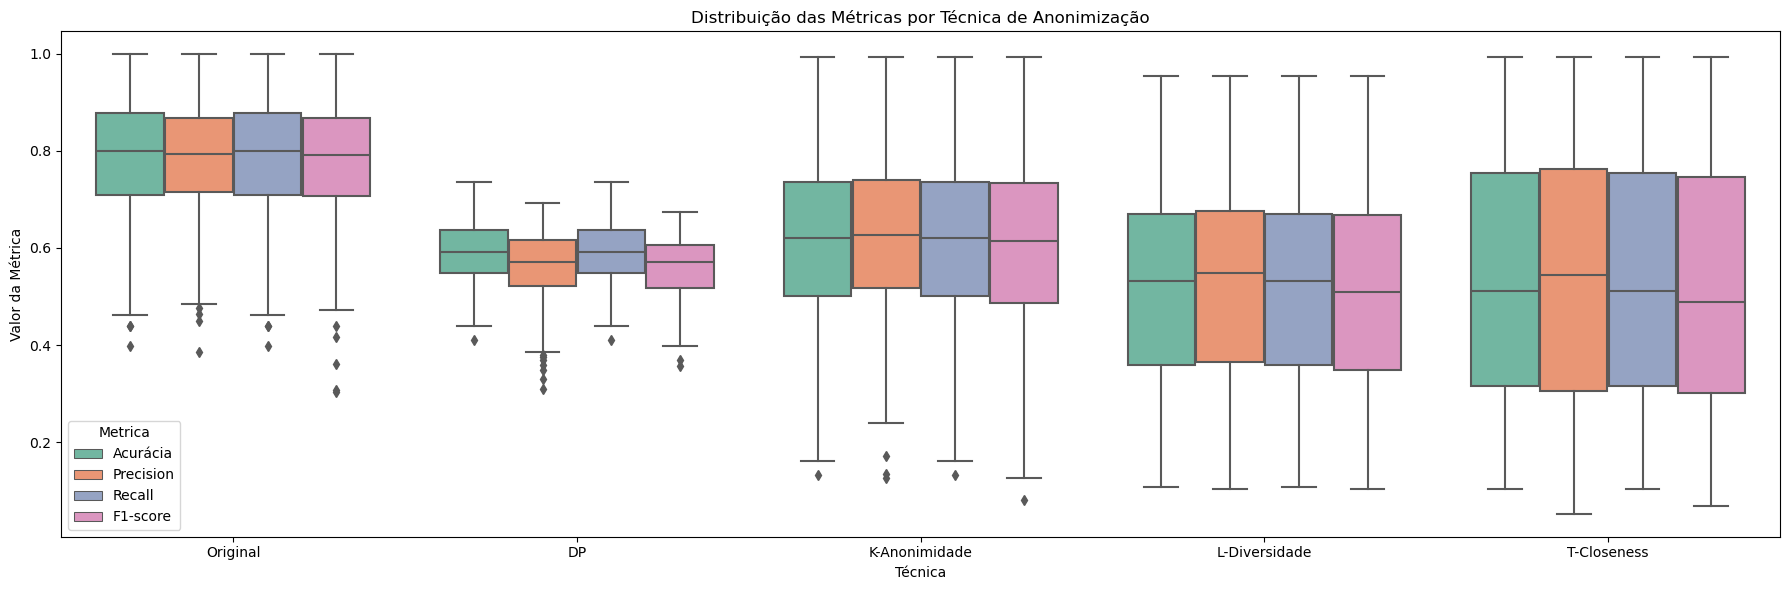

In [3]:
# Boxplot das métricas para cada técnica

plt.figure(figsize=(18, 6))
sns.boxplot(x='Tecnica', y='Valor', data=df_long_2, hue='Metrica', palette='Set2')
plt.title('Distribuição das Métricas por Técnica de Anonimização')
plt.xlabel('Técnica')
plt.ylabel('Valor da Métrica')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



### Utilização e ajuste do banco de dados para realizar o Teste de Wilcoxn + Holm

#### Ajustes

In [4]:
# Filtra todas as colunas de métricas de teste
metric_cols = [col for col in df.columns if "_Teste" in col]

# Transforma em formato long
df_long = pd.melt(df,
                  id_vars=["Banco", "Tipo"],
                  value_vars=metric_cols,
                  var_name="Tecnica_Metrica",
                  value_name="Valor")

# Extrai a técnica (antes do primeiro "_")
df_long["Tecnica"] = df_long["Tecnica_Metrica"].str.extract(r"^(.*?)_")

# Extrai a métrica (entre o primeiro "_" e "_Teste")
df_long["Metrica"] = df_long["Tecnica_Metrica"].str.extract(r"_(.*_Teste)")

# Cria coluna de pareamento
df_long["ID"] = df_long["Banco"]


In [5]:
# Dicionários para mapeamento dos nomes
tecnica_map = {
    'DP': 'DP',
    'K-Anonimidade': 'K-anonymity',
    'L-Diversidade': 'L-diversity',
    'T-Closeness': 'T-closeness'
}

modelo_map = {
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'NaiveBayes': 'NB',
    'KNN': 'KNN',
    'SVM': 'SVM'
}

# Função para aplicar o mapeamento com verificação
def padronizar_nomes(serie, mapeamento):
    return serie.map(lambda x: mapeamento.get(x, x)).astype(str)

# Aplicando as transformações
df_long_2['Tecnica'] = padronizar_nomes(df_long_2['Tecnica'], tecnica_map)
df_long_2['Modelo'] = padronizar_nomes(df_long_2['Modelo'], modelo_map)

# Verificando os resultados
print("\nValores únicos em 'Tecnica' após padronização:")
print(df_long_2['Tecnica'].unique())

print("\nValores únicos em 'Modelo' após padronização:")
print(df_long_2['Modelo'].unique())


Valores únicos em 'Tecnica' após padronização:
['Original' 'DP' 'K-anonymity' 'L-diversity' 'T-closeness']

Valores únicos em 'Modelo' após padronização:
['DT' 'RF' 'SVM' 'NB' 'KNN']


Neste caso, vai ser formatado para ter o Modelo os valores (Decision, Random,....)

In [6]:
df_formatado = df_long_2.pivot(
    index=['Modelo', 'Banco'],
    columns='Metrica',
    values='Valor'
).reset_index().rename(columns={
    'Modelo': 'classifier_name',
    'Banco': 'dataset_name',
    'Acurácia': 'accuracy',
    'F1-score': 'f1_score',
    'Recall': 'recall',
    'Precision': 'precision'
})

# Reordenar as colunas se necessário
df_formatado = df_formatado[['classifier_name', 'dataset_name', 'accuracy', 'f1_score', 'recall', 'precision']]

Neste caso, vai ser formato para ter a tecnica e os valores, sendo que as tecnicas sem os modelos, iria gerar duplicidade, logo, foi agrupado os resultados para poder avaliar as tecnicas

In [7]:
# Primeiro, vamos agregar os dados por Técnica + Banco (calculando a média das métricas por modelo)

df_agrupado = df_long_2.groupby(
    ['Tecnica', 'Banco', 'Metrica']
)['Valor'].mean().reset_index()

# Agora pivotear para ter as métricas como colunas
df_final = df_agrupado.pivot(
    index=['Tecnica', 'Banco'],
    columns='Metrica',
    values='Valor'
).reset_index().rename(columns={
    'Tecnica': 'classifier_name',  # Técnicas serão os grupos comparados
    'Banco': 'dataset_name',
    'Acurácia': 'accuracy',
    'F1-score': 'f1_score',
    'Recall': 'recall',
    'Precision': 'precision'
})

# Ordenar colunas
df_final = df_final[['classifier_name', 'dataset_name', 'accuracy', 'f1_score', 'recall', 'precision']]

In [8]:
# Remover registros do classificador "Original"
df_final_filtrado = df_final[df_final['classifier_name'] != 'Original'].copy()

#### Wilcoxon + Holm (Algoritmos)

In [10]:
import re

def extrair_tecnica(banco, tipo):
    if tipo == 'Original':
        return 'original'
    elif '_dp.xlsx' in banco:
        return 'dp'
    elif '_k_anonimizado_codificado.xlsx' in banco:
        return 'k_anonimizado'
    elif '_l_diverso_codificado.xlsx' in banco:
        return 'l_diverso'
    elif '_t_close_codificado.xlsx' in banco:
        return 't_close'
    else:
        return None  # ou tratar casos não esperados

# Adiciona a coluna Tecnica_Especifica ao DataFrame
df_long['Tecnica_Especifica'] = df_long.apply(lambda row: extrair_tecnica(row['Banco'], row['Tipo']), axis=1)

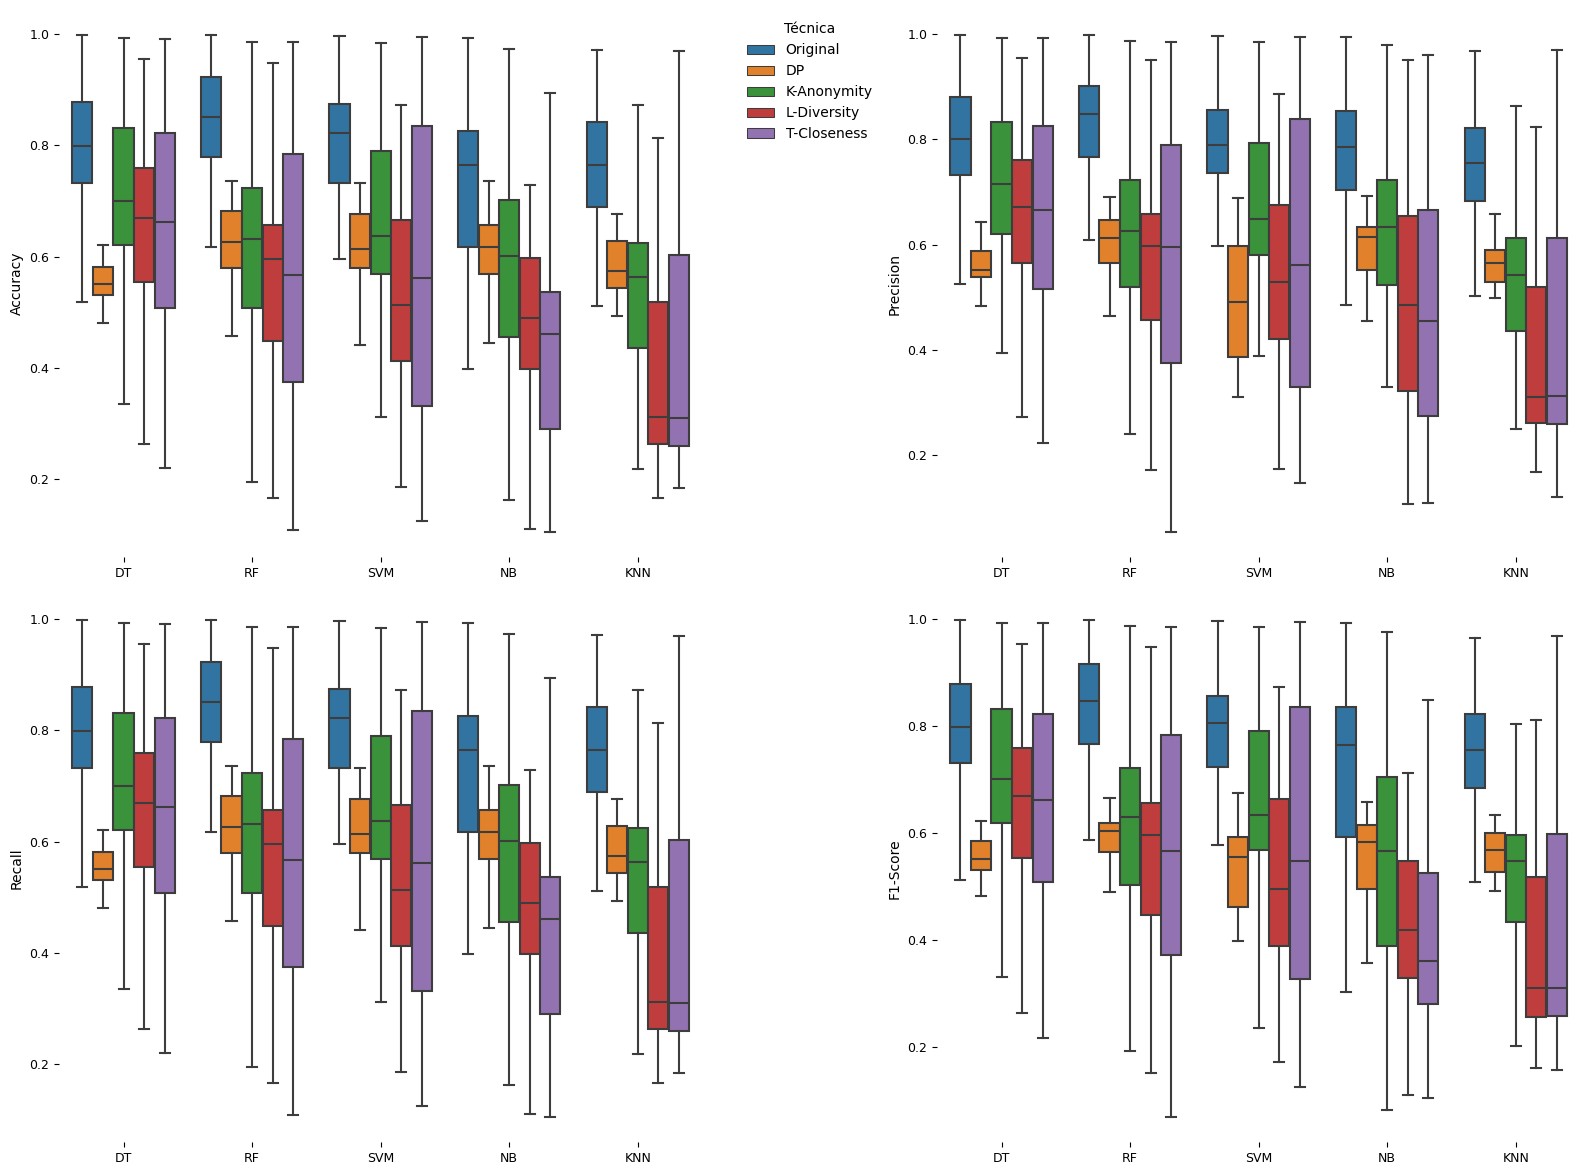

In [11]:
# Configuração de estilo
sns.set_style("whitegrid")
plt.style.use('default')

# 1. Ordem e mapeamento das técnicas
order_techniques = ['original', 'dp', 'k_anonimizado', 'l_diverso', 't_close']

# Mapeamento para nomes legíveis
label_map = {
    'original': 'Original',
    'dp': 'DP',
    'k_anonimizado': 'K-Anonymity',
    'l_diverso': 'L-Diversity',
    't_close': 'T-Closeness'
}

# 2. Configuração de cores mais distintas
color_palette = {
    'original': '#1f77b4',  # Azul
    'dp': '#ff7f0e',        # Laranja
    'k_anonimizado': '#2ca02c',  # Verde
    'l_diverso': '#d62728',      # Vermelho
    't_close': '#9467bd'         # Roxo
}

# Mapeamento de métricas para nomes completos
metric_names = {
    'Acurácia_Teste': 'Acurácia',
    'Precision_Teste': 'Precisão',
    'Recall_Teste': 'Recall',
    'F1-score_Teste': 'F1-Score'
}

# 3. Criar figura 2x2
metricas = df_long['Metrica'].unique()[:4]
n_cols = 2
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
fig.patch.set_visible(False)

# Ajustar espaçamento
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Dicionário de abreviações para os modelos
abreviacoes = {
    'DecisionTree': 'DT',
    'RandomForest': 'RF',
    'SVM': 'SVM',
    'NaiveBayes': 'NB',
    'KNN': 'KNN'
}

for i, (ax, metrica) in enumerate(zip(axes.flatten(), metricas)):
    # Criar boxplot
    sns.boxplot(
        data=df_long[df_long['Metrica'] == metrica],
        x='Tecnica',
        y='Valor',
        hue='Tecnica_Especifica',
        hue_order=order_techniques,
        palette=color_palette,
        showfliers=False,
        linewidth=1.5,
        ax=ax
    )
    
    # Personalizar rótulos do eixo x (algoritmos)
    xticklabels = [abreviacoes.get(tick.get_text(), tick.get_text()) 
                  for tick in ax.get_xticklabels()]
    ax.set_xticklabels(xticklabels)
    
    # Personalizar rótulos da legenda (técnicas)
    handles, labels = ax.get_legend_handles_labels()
    labels = [label_map.get(label, label) for label in labels]
    
    # Remover bordas dos subplots
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    # Remover título do subplot
    ax.set_title('', fontsize=12, pad=10)
    
    # Remover label do eixo x
    ax.set_xlabel('', fontsize=10)
    
    # Definir label do eixo y conforme a métrica
    ax.set_ylabel(metric_names.get(metrica, metrica), fontsize=10)
    
    ax.tick_params(axis='both', which='major', labelsize=9)
    
    # Ajustar legenda
    if i == 0:
        ax.legend(handles, labels, title='Técnica', bbox_to_anchor=(1.05, 1), 
                 frameon=False)
    else:
        ax.get_legend().remove()

plt.suptitle('', y=1.02, fontsize=14)
plt.tight_layout()

# Salvar a figura
plt.savefig('boxplot_grid_colorido.png', dpi=300, bbox_inches='tight', 
            facecolor='white', transparent=True)
plt.show()

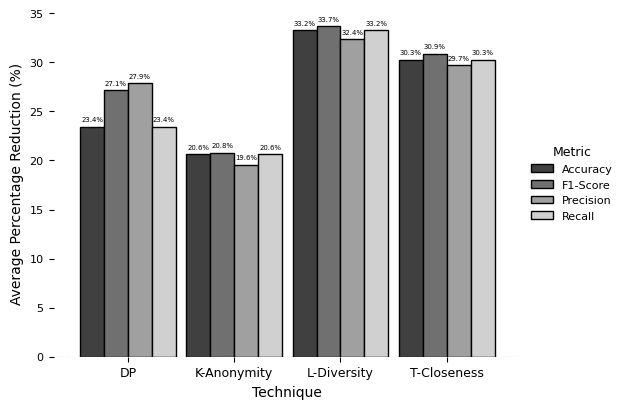

In [17]:
# Color palette by technique

# Grayscale palette
color_palette = {
    'original': '#000000',        # preto
    'dp': '#404040',              # cinza escuro
    'k_anonimizado': '#707070',   # cinza médio-escuro
    'l_diverso': '#A0A0A0',       # cinza médio
    't_close': '#D0D0D0'          # cinza claro
}

# color_palette = {
#     'original': '#1f77b4',
#     'dp': '#ff7f0e',
#     'k_anonimizado': '#2ca02c',
#     'l_diverso': '#d62728',
#     't_close': '#9467bd'
# }

# Label maps
label_map_tec = {
    'original': 'Original',
    'dp': 'DP',
    'k_anonimizado': 'K-Anonymity',
    'l_diverso': 'L-Diversity',
    't_close': 'T-Closeness'
}

label_map_metrica = {
    'Acurácia_Teste': 'Accuracy',
    'F1-score_Teste': 'F1-Score',
    'Recall_Teste': 'Recall',
    'Precision_Teste': 'Precision'
}

# Replace metric names using the map
df_long['Metrica'] = df_long['Metrica'].replace(label_map_metrica)

# 1. Compute means by technique and metric
medias = df_long.groupby(['Tecnica_Especifica', 'Metrica'])['Valor'].mean().unstack()

# 2. Baseline
baseline = medias.loc['original']
medias_sem_original = medias.drop(index='original')

# 3. Average percentage reduction
reducoes_percentuais = (baseline - medias_sem_original) / baseline * 100
reducoes_percentuais = reducoes_percentuais.round(2)

# Traduzir nomes da legenda
reducoes_percentuais.rename(columns={
    'Acurácia': 'Accuracy',
    'Precisão': 'Precision',
    'Recall': 'Recall',
    'F1-Score': 'F1-Score'
}, inplace=True)

# 4. Plot
fig, ax = plt.subplots(figsize=(7.5, 4.2), facecolor='none')

# Organized colors
cores = [color_palette[tec] for tec in reducoes_percentuais.index]

bars = reducoes_percentuais.plot(
    kind='bar',
    ax=ax,
    edgecolor='black',
    width=0.9,
    color=cores
)

# Labels on bars
for container in bars.containers:
    for bar in container:
        height = bar.get_height()
        if not np.isnan(height):
            ax.annotate(
                f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center',
                va='bottom',
                fontsize=5
            )

# Axis aesthetics
ax.set_ylabel('Average Percentage Reduction (%)', fontsize=10)
ax.set_xlabel('Technique', fontsize=10)
ax.set_xticklabels(
    reducoes_percentuais.index.map(label_map_tec),
    rotation=0,
    fontsize=9
)

ax.tick_params(axis='y', labelsize=8)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

# Legend
ax.legend(
    title='Metric',
    fontsize=8,
    title_fontsize=9,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save as PDF (high-quality vector)
plt.savefig(
    'average_percentage_reduction.pdf',
    format='pdf',
    bbox_inches='tight',
    transparent=True
)

plt.show()

In [14]:
tabela_apendice = (
    df_long
    .groupby(['Tecnica_Especifica', 'Metrica'])['Valor']
    .mean()
    .unstack()
    .round(4)
)

print(tabela_apendice)

Metrica             Accuracy  F1-Score  Precision  Recall
Tecnica_Especifica                                       
dp                    0.5959    0.5589     0.5621  0.5959
k_anonimizado         0.6177    0.6078     0.6270  0.6177
l_diverso             0.5195    0.5089     0.5271  0.5195
original              0.7783    0.7671     0.7796  0.7783
t_close               0.5428    0.5303     0.5478  0.5428


#### Ajuste para não conter o original na analise

In [ ]:
# FILTRAR APENAS DATASETS ANONIMIZADOS


anon_suffixes = (
    '_dp',
    '_k_anonimizado_codificado',
    '_l_diverso_codificado',
    '_t_close_codificado'
)

df_formatado_filtrado = df_formatado[
    df_formatado['dataset_name'].str.contains(
        '|'.join(anon_suffixes),
        regex=True
    )
].copy()


In [ ]:
def perform_statistical_tests(df_perf, metrics=None, alpha=0.05):
    """
    Perform Friedman and Wilcoxon-Holm post-hoc tests for multiple metrics.
    
    Args:
        df_perf: DataFrame with columns 'classifier_name', 'dataset_name', and metric columns
        metrics: list of metrics to analyze (default: ['accuracy', 'f1_score', 'recall', 'precision'])
        alpha: significance level (default: 0.05)
    
    Returns:
        dict: Dictionary with results for each metric
    """
    if metrics is None:
        metrics = ['accuracy', 'f1_score', 'recall', 'precision']
    
    results = {}
    
    for metric in metrics:
        # Count number of datasets per classifier
        df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
        max_nb_datasets = df_counts['count'].max()
        classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
        m = len(classifiers)
        
        # Friedman test
        friedman_stat, friedman_p = friedmanchisquare(*(
            np.array(df_perf.loc[df_perf['classifier_name'] == c][metric], dtype=np.float64)
            for c in classifiers))
        
        friedman_results = pd.DataFrame({
            'Test': ['Friedman'],
            'Statistic': [friedman_stat],
            'p-value': [friedman_p],
            'Significant': [friedman_p < alpha],
            'Alpha': [alpha]
        })
        
        # Wilcoxon signed-rank tests with Holm correction and performance differences
        p_values = []
        for i in range(m - 1):
            classifier_1 = classifiers[i]
            perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1][metric], 
                             dtype=np.float64)
            for j in range(i + 1, m):
                classifier_2 = classifiers[j]
                perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2][metric], 
                                 dtype=np.float64)
                # Calculate p-value and performance differences
                p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
                mean_diff = perf_1.mean() - perf_2.mean()
                median_diff = np.median(perf_1) - np.median(perf_2)
                p_values.append((classifier_1, classifier_2, p_value, mean_diff, median_diff, False))
        
        # Apply Holm correction
        k = len(p_values)
        p_values.sort(key=operator.itemgetter(2))  # Sort by p-value
        
        for i in range(k):
            new_alpha = float(alpha / (k - i))
            if p_values[i][2] <= new_alpha:
                p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], 
                              p_values[i][3], p_values[i][4], True)  # Update significance
            else:
                break
        
        # Create Wilcoxon results DataFrame
        wilcoxon_results = pd.DataFrame(p_values, 
                                      columns=['Classifier 1', 'Classifier 2', 
                                               'p-value', 'Mean Diff', 'Median Diff',
                                               'Significant'])
        
        # Calculate average ranks (lower rank = better)
        sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(
            ['classifier_name', 'dataset_name'])
        rank_data = np.array(sorted_df_perf[metric]).reshape(m, max_nb_datasets)
        df_ranks = pd.DataFrame(data=rank_data, 
                               index=np.sort(classifiers), 
                               columns=np.unique(sorted_df_perf['dataset_name']))
        average_ranks = df_ranks.rank(ascending=False).mean(axis=1).sort_values(ascending=False)
        
        results[metric] = {
            'friedman': friedman_results,
            'wilcoxon': wilcoxon_results,
            'average_ranks': average_ranks
        }
    
    return results

# Realizar os testes estatísticos para todas as métricas
results = perform_statistical_tests(df_formatado_filtrado)

# Exibir e salvar os resultados para cada métrica
for metric, res in results.items():
    print(f"\n=== Resultados para {metric} ===")
    
    print("\n=== Friedman Test (Global Differences) ===")
    print(res['friedman'].to_string(index=False))
    print("\n→ Conclusão:", "Há diferenças significativas entre os classificadores." 
          if res['friedman']['Significant'].iloc[0] else "Não há diferenças globais significativas.")

    print("\n=== Wilcoxon-Holm Post-Hoc Tests ===")
    print(res['wilcoxon'][['Classifier 1', 'Classifier 2', 'p-value', 'Mean Diff', 'Significant']].to_string(index=False))

    print("\n=== Average Ranks (Lower = Better) ===")
    print(res['average_ranks'].to_string())
    print("\n→ Classificador com melhor rank médio:", res['average_ranks'].idxmin())

    # Salvar resultados em CSV
    res['friedman'].to_csv(f'friedman_results_{metric}.csv', index=False)
    res['wilcoxon'].to_csv(f'wilcoxon_results_{metric}.csv', index=False)
    res['average_ranks'].to_csv(f'average_ranks_{metric}.csv', header=['Average Rank'])

##### Wilcoxon + Holm (Algoritmos) - CD 


=== Processing accuracy ===

Classifiers being compared:
['DT' 'KNN' 'NB' 'RF' 'SVM']

Number of wins (best rank=1.0):
DT     56.0
KNN     5.0
NB     12.0
RF     36.0
SVM    39.0
dtype: float64

Average Ranks for Critical Difference - Accuracy:
KNN    4.040000
NB     3.513333
RF     2.543333
DT     2.486667
SVM    2.416667
dtype: float64

Critical Difference (CD) at alpha=0.05: 0.4981
Number of datasets: 150
Number of classifiers: 5
Interpretation: If the difference between two average ranks is greater than CD,
the difference is statistically significant.
('KNN', 'SVM', 1.0126062799273978e-16, True)
('DT', 'KNN', 4.716688839415132e-15, True)
('KNN', 'RF', 1.2088728817451721e-14, True)
('DT', 'NB', 2.0739696014015589e-10, True)
('NB', 'SVM', 1.3667400450299994e-08, True)
('NB', 'RF', 4.5300206206575174e-07, True)
('DT', 'RF', 0.0011981193177846398, True)
('KNN', 'NB', 0.0038596538938945823, True)
('DT', 'SVM', 0.0464118661716632, False)
('RF', 'SVM', 0.6464204891085864, False)


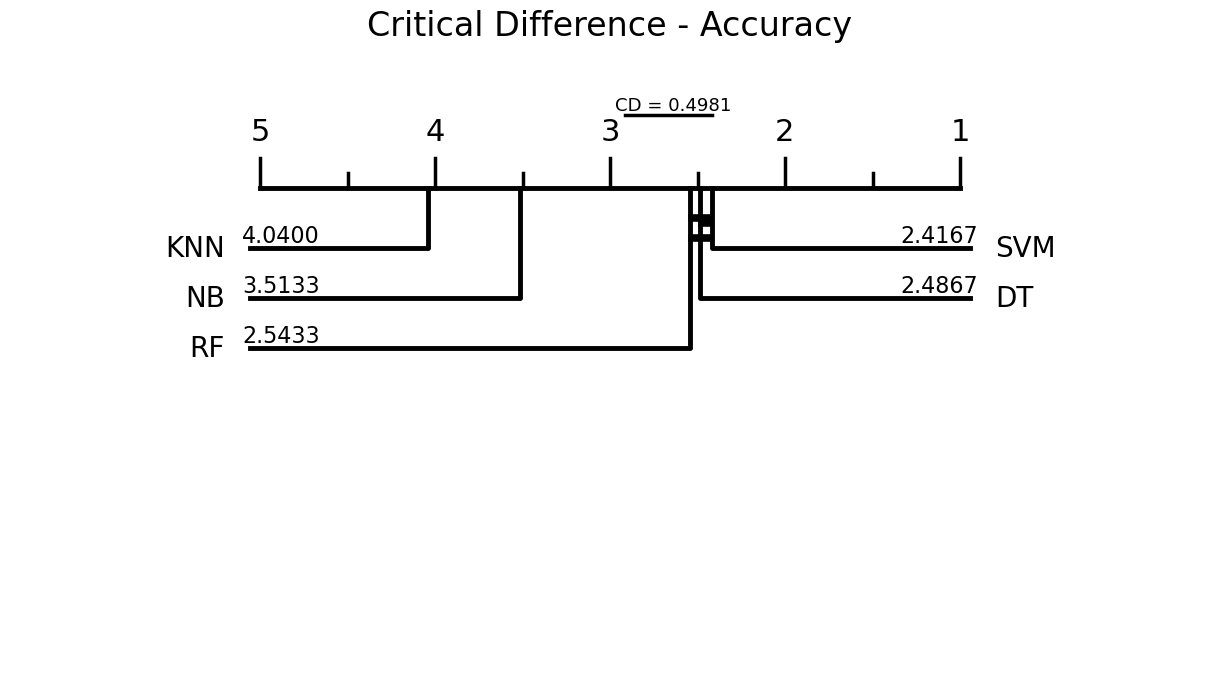


=== Processing f1_score ===

Classifiers being compared:
['DT' 'KNN' 'NB' 'RF' 'SVM']

Number of wins (best rank=1.0):
DT     61.0
KNN     7.0
NB     14.0
RF     34.0
SVM    34.0
dtype: float64

Average Ranks for Critical Difference - F1-score:
KNN    3.840000
NB     3.596667
SVM    2.876667
RF     2.480000
DT     2.206667
dtype: float64

Critical Difference (CD) at alpha=0.05: 0.4981
Number of datasets: 150
Number of classifiers: 5
Interpretation: If the difference between two average ranks is greater than CD,
the difference is statistically significant.
('DT', 'KNN', 4.884765464324416e-18, True)
('DT', 'NB', 4.541294451828467e-16, True)
('KNN', 'RF', 1.7316838799112727e-14, True)
('NB', 'RF', 5.57821198903002e-10, True)
('KNN', 'SVM', 4.564711029260941e-09, True)
('DT', 'SVM', 2.4453059024255112e-08, True)
('NB', 'SVM', 5.508848713831123e-07, True)
('DT', 'RF', 2.356671157663994e-05, True)
('RF', 'SVM', 0.038236866240415335, False)
('KNN', 'NB', 0.21386464425424456, False)


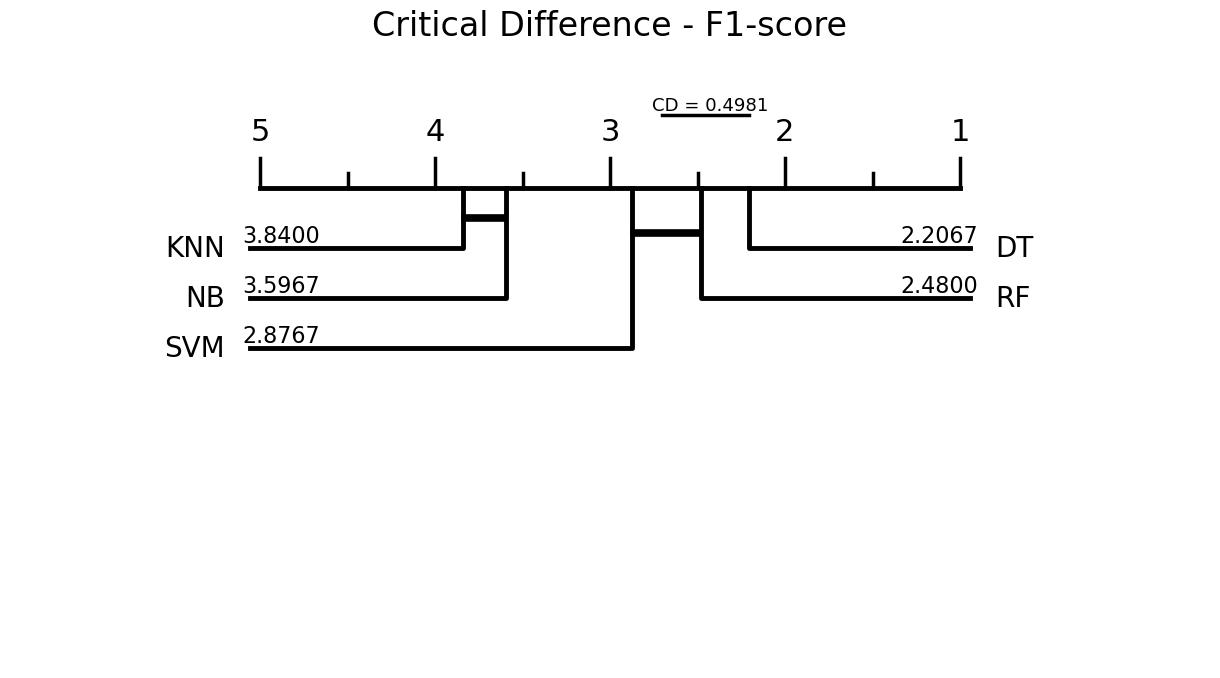


=== Processing recall ===

Classifiers being compared:
['DT' 'KNN' 'NB' 'RF' 'SVM']

Number of wins (best rank=1.0):
DT     56.0
KNN     5.0
NB     12.0
RF     36.0
SVM    39.0
dtype: float64

Average Ranks for Critical Difference - Recall:
KNN    4.040000
NB     3.513333
RF     2.543333
DT     2.486667
SVM    2.416667
dtype: float64

Critical Difference (CD) at alpha=0.05: 0.4981
Number of datasets: 150
Number of classifiers: 5
Interpretation: If the difference between two average ranks is greater than CD,
the difference is statistically significant.
('KNN', 'SVM', 1.0126062799273978e-16, True)
('DT', 'KNN', 4.716688839415132e-15, True)
('KNN', 'RF', 1.2088728817451721e-14, True)
('DT', 'NB', 2.0739696014015589e-10, True)
('NB', 'SVM', 1.3667400450299994e-08, True)
('NB', 'RF', 4.5300206206575174e-07, True)
('DT', 'RF', 0.0011981193177846398, True)
('KNN', 'NB', 0.0038596538938945823, True)
('DT', 'SVM', 0.0464118661716632, False)
('RF', 'SVM', 0.6464204891085864, False)


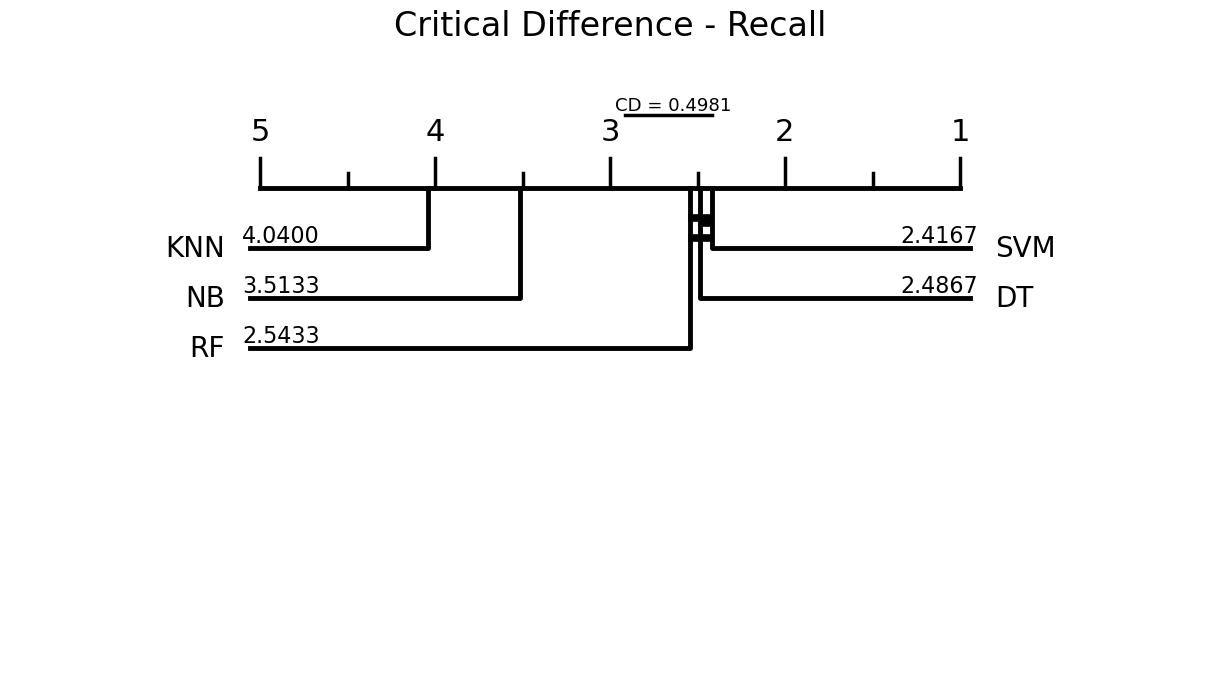


=== Processing precision ===

Classifiers being compared:
['DT' 'KNN' 'NB' 'RF' 'SVM']

Number of wins (best rank=1.0):
DT     50.0
KNN     4.0
NB     25.0
RF     34.0
SVM    37.0
dtype: float64

Average Ranks for Critical Difference - Precision:
KNN    4.066667
NB     3.263333
SVM    2.810000
RF     2.566667
DT     2.293333
dtype: float64

Critical Difference (CD) at alpha=0.05: 0.4981
Number of datasets: 150
Number of classifiers: 5
Interpretation: If the difference between two average ranks is greater than CD,
the difference is statistically significant.
('DT', 'KNN', 3.8489992083703675e-19, True)
('KNN', 'RF', 2.6678520373948154e-15, True)
('DT', 'NB', 1.0444243408294464e-09, True)
('DT', 'SVM', 6.102712466995661e-08, True)
('KNN', 'SVM', 1.1147879560237566e-07, True)
('KNN', 'NB', 1.8952418478374506e-05, True)
('NB', 'RF', 4.122203463487172e-05, True)
('DT', 'RF', 4.257975502253859e-05, True)
('NB', 'SVM', 0.02869173943404934, False)
('RF', 'SVM', 0.09439277156313693, False)


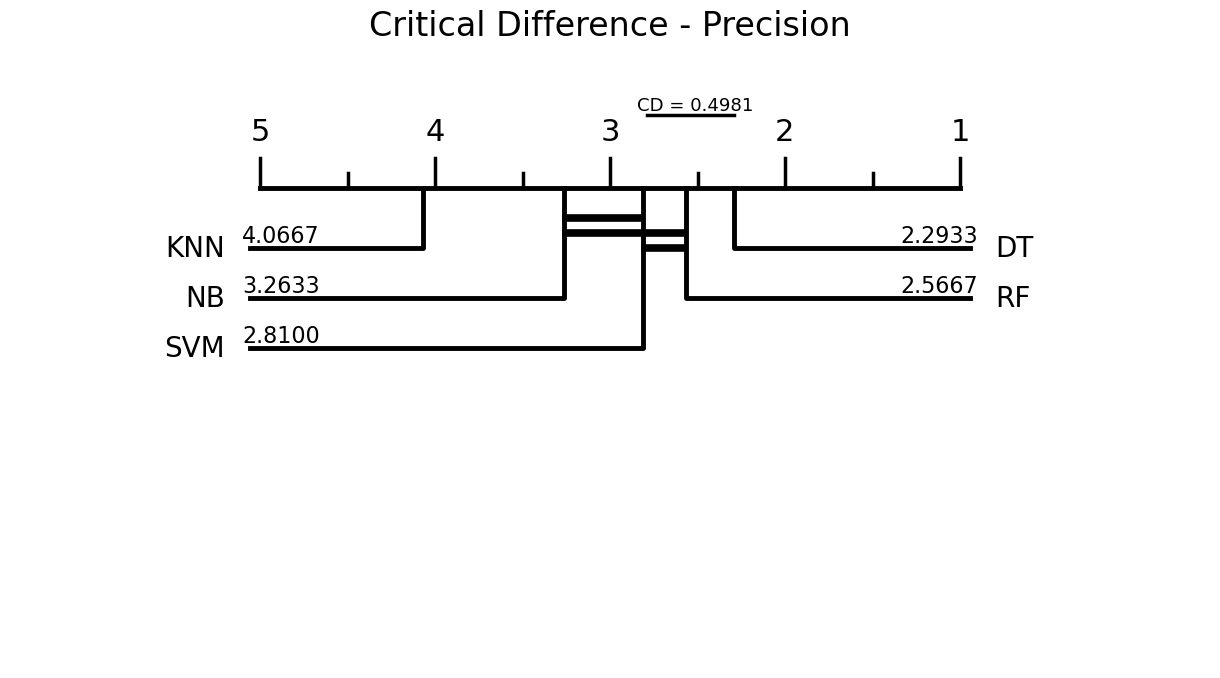

In [ ]:
def form_cliques(p_values, names):
    """
    Creates cliques of classifiers that are not significantly different from each other.
    """
    cliques = []
    for i, name1 in enumerate(names):
        clique = [i]
        for j, name2 in enumerate(names):
            if i == j:
                continue
            for pval in p_values:
                if (name1 == pval[0] and name2 == pval[1]) or (name1 == pval[1] and name2 == pval[0]):
                    if not pval[3]:  # Didn't reject H0 => Not significantly different
                        clique.append(j)
        clique = sorted(set(clique))
        if clique not in cliques:
            cliques.append(clique)
    return cliques

def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=12, textspace=2, reverse=False, filename=None, labels=True, **kwargs):
    """
    Draws a CD graph with improved layout and spacing.
    """
    try:
        import matplotlib
        import matplotlib.pyplot as plt
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("Function graph_ranks requires matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0:
            return len(l[0]) + n
        else:
            return n

    def mxrange(lr):
        if not len(lr):
            yield ()
        else:
            index = lr[0]
            if isinstance(index, int):
                index = [index]
            for a in range(*index):
                for b in mxrange(lr[1:]):
                    yield tuple([a] + list(b))

    def print_figure(fig, *args, **kwargs):
        canvas = FigureCanvasAgg(fig)
        canvas.print_figure(*args, **kwargs)

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    # Layout parameters
    cline = 0.8
    distanceh = 0.5
    space_between_names = 0.5
    rank_fontsize = 22
    name_fontsize = 20
    label_fontsize = 16

    minnotsignificant = max(2 * 0.3, 0)
    height = cline + ((len(nnames) + 1) * 0.7) + minnotsignificant
    scalewidth = width - 2 * textspace

    fig = plt.figure(figsize=(width, height), dpi=100)
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l):
        return [a * hf for a in l]

    def wfl(l):
        return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    line([(textspace, cline), (width - textspace, cline)], linewidth=3.5)

    bigtick = 0.6
    smalltick = 0.3
    linewidth = 3.5
    linewidth_sign = 5.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2.5)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.12, str(a),
             ha="center", va="bottom", size=rank_fontsize)

    k = len(ssums)

    def filter_names(name):
        return name

    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + 0.6, chei - 0.12, format(ssums[i], '.4f'),
                 ha="right", va="center", size=label_fontsize)
        text(textspace - 0.35, chei, filter_names(nnames[i]),
             ha="right", va="center", size=name_fontsize)

    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + scalewidth - 0.6, chei - 0.12, format(ssums[i], '.4f'),
                 ha="left", va="center", size=label_fontsize)
        text(textspace + scalewidth + 0.35, chei, filter_names(nnames[i]),
             ha="left", va="center", size=name_fontsize)

    start = cline + 0.3
    side = -0.02
    height = 0.15

    cliques = form_cliques(p_values, nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.35
            achieved_half = True
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign)
        start += height

    # Adicionando a linha do Critical Difference (CD)
    if cd is not None:
        # Posição vertical da linha CD (acima das cliques)
        cd_y = 0.07
        
        # Ponto de início (melhor rank)
        cd_x_start = rankpos(min(ssums))
        
        # Ponto final (melhor rank + CD)
        cd_x_end = rankpos(min(ssums) + cd)
        
        # Desenha a linha CD
        line([(cd_x_start, cd_y), (cd_x_end, cd_y)], 
             color='black', 
             linestyle='-', 
             linewidth=2.5)
        
        # Adiciona texto com o valor do CD
        text(cd_x_end - 0.1, cd_y - 0.1, f'CD = {cd:.4f}', 
             ha='left', 
             va='center', 
             color='black',
             size=label_fontsize-3)

def wilcoxon_holm(alpha=0.05, df_perf=None):
    """
    Applies the wilcoxon signed rank test between each pair of algorithm and then use Holm
    to reject the null's hypothesis.
    Returns:
    - p_values: List of pairwise comparisons
    - average_ranks: Average ranks for each classifier
    - max_nb_datasets: Number of datasets used
    - cd: Critical difference value
    """
    print("\nClassifiers being compared:")
    print(pd.unique(df_perf['classifier_name']))
    
    df_counts = pd.DataFrame({'count': df_perf.groupby(['classifier_name']).size()}).reset_index()
    max_nb_datasets = df_counts['count'].max()
    classifiers = list(df_counts.loc[df_counts['count'] == max_nb_datasets]['classifier_name'])
    
    # Friedman test
    friedman_p_value = friedmanchisquare(*(
        np.array(df_perf.loc[df_perf['classifier_name'] == c]['accuracy'], dtype=np.float64)
        for c in classifiers))[1]
    
    if friedman_p_value >= alpha:
        print(f"Friedman p-value: {friedman_p_value:.4f} >= alpha {alpha}")
        print('The null hypothesis over the entire classifiers cannot be rejected')
        return [], pd.Series(), 0, None
    
    m = len(classifiers)
    p_values = []
    
    # Pairwise comparisons
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_1]['accuracy'], 
                         dtype=np.float64)
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = np.array(df_perf.loc[df_perf['classifier_name'] == classifier_2]['accuracy'], 
                             dtype=np.float64)
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))
    
    # Holm correction
    k = len(p_values)
    p_values.sort(key=operator.itemgetter(2))
    
    for i in range(k):
        new_alpha = float(alpha / (k - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            break
    
    # Compute average ranks
    sorted_df_perf = df_perf.loc[df_perf['classifier_name'].isin(classifiers)].sort_values(
        ['classifier_name', 'dataset_name'])
    rank_data = np.array(sorted_df_perf['accuracy']).reshape(m, max_nb_datasets)
    
    df_ranks = pd.DataFrame(data=rank_data, index=np.sort(classifiers), 
                           columns=np.unique(sorted_df_perf['dataset_name']))
    
    print("\nNumber of wins (best rank=1.0):")
    print(df_ranks.rank(ascending=False)[df_ranks.rank(ascending=False) == 1.0].sum(axis=1))
    
    average_ranks = df_ranks.rank(ascending=False).mean(axis=1).sort_values(ascending=False)
    
    # Calculate Critical Difference (CD)
    # Using Demšar's formula: CD = q_alpha * sqrt(k(k+1)/6N)
    # Where:
    # q_alpha is based on the Studentized range statistic
    # k is number of classifiers
    # N is number of datasets
    
    # Values from Demšar's paper for alpha=0.05
    q_alpha_table = {
        2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 
        6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 
        10: 3.164
    }
    
    q_alpha = q_alpha_table.get(m, 2.569)  # Default to k=4 if m not in table
    cd = q_alpha * math.sqrt(m * (m + 1) / (6 * max_nb_datasets))
    
    return p_values, average_ranks, max_nb_datasets, cd

def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=True):
    """
    Draws the critical difference diagram and shows CD value in output.
    """
    p_values, average_ranks, n_datasets, cd = wilcoxon_holm(df_perf=df_perf, alpha=alpha)

    print(f"\nAverage Ranks for {title}:")
    print(average_ranks)
    
    if cd is not None:
        print(f"\nCritical Difference (CD) at alpha={alpha}: {cd:.4f}")
        print(f"Number of datasets: {n_datasets}")
        print(f"Number of classifiers: {len(average_ranks)}")
        print("Interpretation: If the difference between two average ranks is greater than CD,")
        print("the difference is statistically significant.")

    for p in p_values:
        print(p)

    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=cd, reverse=True, width=12, textspace=2.5, labels=labels)

    font = {'family': 'sans-serif',
            'color': 'black',
            'weight': 'normal',
            'size': 24,
            }
    
    fig = plt.gcf()
    if title:
        plt.title(title, fontdict=font, y=1.08, x=0.5, pad=20)
    
    plt.subplots_adjust(top=0.85)
    
    filename = title.lower().replace(' ', '_').replace('-', '_') + '_cd_diagram.png'
    fig.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show(block=True)
    plt.close(fig)

def draw_cd_diagram_for_all_metrics(df_perf=None, alpha=0.05, title_prefix='', labels=True):
    metrics = ['accuracy', 'f1_score', 'recall', 'precision']
    
    for metric in metrics:
        print(f"\n=== Processing {metric} ===")
        
        temp_df = df_perf[['classifier_name', 'dataset_name', metric]].copy()
        temp_df = temp_df.rename(columns={metric: 'accuracy'})
        
        metric_title = metric.capitalize().replace('_', '-')
        title = f"{title_prefix}{metric_title}"
        
        draw_cd_diagram(df_perf=temp_df, alpha=alpha, title=title, labels=labels)


draw_cd_diagram_for_all_metrics(df_perf=df_formatado_filtrado, title_prefix='Critical Difference - ', labels=True)

#### Wilcoxon + Holm (Tecnicas de Anonimização) - CD 

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import friedmanchisquare, wilcoxon

def normalize_dataset_name(name):
    """Remove os sufixos das técnicas e extensões .xlsx dos nomes dos datasets"""
    name = str(name)  # Garantir que é string
    
    # Primeiro remover .xlsx se existir
    if name.endswith('.xlsx'):
        name = name[:-5]
    
    # Depois remover sufixos das técnicas
    suffixes = [
        '_dp',
        '_k_anonimizado_codificado',
        '_l_diverso_codificado', 
        '_t_close_codificado'
    ]
    for suffix in suffixes:
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name

# Criar uma coluna com o nome normalizado do dataset
df_final_filtrado['dataset_base'] = df_final_filtrado['dataset_name'].apply(normalize_dataset_name)

# Verificar os nomes normalizados
print("Nomes originais vs normalizados:")
print(df_final_filtrado[['dataset_name', 'dataset_base']].drop_duplicates())

def perform_statistical_tests(df_perf, metrics=None, alpha=0.05):
    """
    Perform Friedman and Wilcoxon-Holm post-hoc tests for multiple metrics.
    
    Args:
        df_perf: DataFrame with performance data
        metrics: list of metrics to analyze
        alpha: significance level
    """
    if metrics is None:
        metrics = ['accuracy', 'f1_score', 'recall', 'precision']
    
    results = {}
    
    for metric in metrics:
        print(f"\n=== Processando métrica: {metric} ===")
        
        # Criar tabela pivot verificando completude
        pivot_data = df_perf.pivot_table(
            index='dataset_base',
            columns='classifier_name',
            values=metric,
            aggfunc='mean'  # Usar média caso haja múltiplos valores
        )
        
        # Verificar completude dos dados
        missing_data = pivot_data.isna().sum().sum()
        if missing_data > 0:
            print(f"Aviso: Existem {missing_data} valores faltantes na matriz de dados.")
            print("Técnicas com dados faltantes:")
            print(pivot_data.isna().sum())
            
            # Remover linhas com qualquer valor faltante
            pivot_data = pivot_data.dropna()
            
            if len(pivot_data) < 2:
                print("Não há datasets suficientes com dados completos para todas as técnicas")
                continue
        
        classifiers = pivot_data.columns.tolist()
        datasets = pivot_data.index.tolist()
        
        print(f"\nDatasets incluídos: {len(datasets)}")
        print(f"Técnicas incluídas: {classifiers}")
        
        # Friedman test
        try:
            friedman_stat, friedman_p = friedmanchisquare(*[pivot_data[c].values for c in classifiers])
            
            friedman_results = pd.DataFrame({
                'Test': ['Friedman'],
                'Statistic': [friedman_stat],
                'p-value': [friedman_p],
                'Significant': [friedman_p < alpha],
                'Alpha': [alpha],
                'Classifiers': [len(classifiers)],
                'Datasets': [len(datasets)]
            })
            
        except Exception as e:
            print(f"Erro no teste de Friedman: {str(e)}")
            continue
        
        # Wilcoxon signed-rank tests com correção de Holm
        comparisons = []
        m = len(classifiers)
        
        for i in range(m - 1):
            for j in range(i + 1, m):
                tech1, tech2 = classifiers[i], classifiers[j]
                
                try:
                    stat, p_value = wilcoxon(
                        pivot_data[tech1].values,
                        pivot_data[tech2].values,
                        zero_method='pratt'
                    )
                    mean_diff = np.mean(pivot_data[tech1] - pivot_data[tech2])
                    median_diff = np.median(pivot_data[tech1] - pivot_data[tech2])
                    comparisons.append((tech1, tech2, p_value, mean_diff, median_diff, False))
                except Exception as e:
                    print(f"Erro no Wilcoxon para {tech1} vs {tech2}: {str(e)}")
        
        # Aplicar correção de Holm
        if comparisons:
            comparisons.sort(key=lambda x: x[2])  # Ordenar por p-value
            k = len(comparisons)
            
            for i in range(k):
                adjusted_alpha = alpha / (k - i)
                if comparisons[i][2] <= adjusted_alpha:
                    comparisons[i] = (*comparisons[i][:5], True)
                else:
                    # Marcar restantes como não significativos
                    for r in range(i, k):
                        comparisons[r] = (*comparisons[r][:5], False)
                    break
            
            wilcoxon_results = pd.DataFrame(
                comparisons,
                columns=['Technique 1', 'Technique 2', 'p-value', 
                        'Mean Diff', 'Median Diff', 'Significant']
            )
        else:
            wilcoxon_results = pd.DataFrame()
        
        # Calcular ranks médios
        rank_data = pivot_data.rank(axis=1, ascending=False)
        average_ranks = rank_data.mean().sort_values()
        
        # Armazenar resultados
        results[metric] = {
            'friedman': friedman_results,
            'wilcoxon': wilcoxon_results,
            'average_ranks': average_ranks,
            'datasets_used': datasets
        }
        
        # Exibir resultados
        print("\nTeste de Friedman:")
        print(friedman_results.to_string(index=False))
        
        if not wilcoxon_results.empty:
            print("\nTestes Post-Hoc (Wilcoxon-Holm):")
            print(wilcoxon_results[['Technique 1', 'Technique 2', 'p-value', 
                                  'Mean Diff', 'Significant']].to_string(index=False))
        else:
            print("\nNenhum teste post-hoc realizado")
        
        print("\nRanks Médios (1 = melhor):")
        print(average_ranks.to_string())
        print(f"\nMelhor técnica: {average_ranks.idxmin()} (rank: {average_ranks.min():.2f})")
    
    return results

# Executar os testes estatísticos
results = perform_statistical_tests(df_final_filtrado)

# Salvar resultados em arquivos
for metric, res in results.items():
    res['friedman'].to_csv(f'results_friedman_{metric}.csv', index=False)
    res['wilcoxon'].to_csv(f'results_wilcoxon_{metric}.csv', index=False)
    res['average_ranks'].to_csv(f'results_ranks_{metric}.csv', header=['Rank'])

##### Wilcoxon + Holm (Tecnicas) - CD 

In [ ]:
import math
import operator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx
from scipy.stats import friedmanchisquare, wilcoxon

def form_cliques(p_values, names):
    """
    Creates cliques of classifiers that are not significantly different from each other.
    """
    cliques = []
    for i, name1 in enumerate(names):
        clique = [i]
        for j, name2 in enumerate(names):
            if i == j:
                continue
            for pval in p_values:
                if (name1 == pval[0] and name2 == pval[1]) or (name1 == pval[1] and name2 == pval[0]):
                    if not pval[3]:  # Didn't reject H0 => Not significantly different
                        clique.append(j)
        clique = sorted(set(clique))
        if clique not in cliques:
            cliques.append(clique)
    return cliques

def normalize_dataset_name(dataset_name):
    """Normalize dataset names by removing version numbers and paths."""
    # Remove directory paths if present
    name = dataset_name.split('/')[-1]
    # Remove file extensions
    name = name.split('.')[0]
    # Remove version numbers (like _v1, -v2 etc.)
    name = name.split('_v')[0].split('-v')[0]
    return name

def graph_ranks(avranks, names, p_values, cd=None, cdmethod=None, lowv=None, highv=None,
                width=12, textspace=2, reverse=False, filename=None, labels=True, **kwargs):
    """Draws a CD graph with improved layout and spacing."""
    try:
        import matplotlib
        import matplotlib.pyplot as plt
        from matplotlib.backends.backend_agg import FigureCanvasAgg
    except ImportError:
        raise ImportError("Function graph_ranks requires matplotlib.")

    width = float(width)
    textspace = float(textspace)

    def nth(l, n):
        return [a[n] for a in l]

    def lloc(l, n):
        if n < 0:
            return len(l[0]) + n
        else:
            return n

    def mxrange(lr):
        if not len(lr):
            yield ()
        else:
            index = lr[0]
            if isinstance(index, int):
                index = [index]
            for a in range(*index):
                for b in mxrange(lr[1:]):
                    yield tuple([a] + list(b))

    def print_figure(fig, *args, **kwargs):
        canvas = FigureCanvasAgg(fig)
        canvas.print_figure(*args, **kwargs)

    def rankpos(rank):
        if not reverse:
            a = rank - lowv
        else:
            a = highv - rank
        return textspace + scalewidth / (highv - lowv) * a

    sums = avranks
    nnames = names
    ssums = sums

    if lowv is None:
        lowv = min(1, int(math.floor(min(ssums))))
    if highv is None:
        highv = max(len(avranks), int(math.ceil(max(ssums))))

    # Layout parameters - increased for better spacing
    cline = 1.0  # Increased from 0.8
    distanceh = 0.6  # Increased from 0.5
    space_between_names = 0.6  # Increased from 0.5
    rank_fontsize = 22
    name_fontsize = 20
    label_fontsize = 16

    minnotsignificant = max(2 * 0.3, 0)
    height = cline + ((len(nnames) + 1) * 0.8) + minnotsignificant  # Increased multiplier
    scalewidth = width - 2 * textspace

    fig = plt.figure(figsize=(width, height), dpi=100)
    fig.set_facecolor('white')
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()

    hf = 1. / height
    wf = 1. / width

    def hfl(l):
        return [a * hf for a in l]

    def wfl(l):
        return [a * wf for a in l]

    ax.plot([0, 1], [0, 1], c="w")
    ax.set_xlim(0, 1)
    ax.set_ylim(1, 0)

    def line(l, color='k', **kwargs):
        ax.plot(wfl(nth(l, 0)), hfl(nth(l, 1)), color=color, **kwargs)

    def text(x, y, s, *args, **kwargs):
        ax.text(wf * x, hf * y, s, *args, **kwargs)

    # Base line
    line([(textspace, cline), (width - textspace, cline)], linewidth=3.5)

    # Ticks and labels
    bigtick = 0.6
    smalltick = 0.3
    linewidth = 3.5
    linewidth_sign = 5.5

    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = smalltick
        if a == int(a):
            tick = bigtick
        line([(rankpos(a), cline - tick / 2),
              (rankpos(a), cline)],
             linewidth=2.5)

    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.15, str(a),  # Increased spacing
             ha="center", va="bottom", size=rank_fontsize)

    k = len(ssums)

    def filter_names(name):
        return name

    # Left-side classifiers
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsignificant + i * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace - 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + 0.7, chei - 0.15, format(ssums[i], '.4f'),  # Increased spacing
                 ha="right", va="center", size=label_fontsize)
        text(textspace - 0.4, chei, filter_names(nnames[i]),  # Increased spacing
             ha="right", va="center", size=name_fontsize)

    # Right-side classifiers
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsignificant + (k - i - 1) * space_between_names
        line([(rankpos(ssums[i]), cline),
              (rankpos(ssums[i]), chei),
              (textspace + scalewidth + 0.1, chei)],
             linewidth=linewidth)
        if labels:
            text(textspace + scalewidth - 0.7, chei - 0.15, format(ssums[i], '.4f'),
                 ha="left", va="center", size=label_fontsize)
        text(textspace + scalewidth + 0.4, chei, filter_names(nnames[i]),
             ha="left", va="center", size=name_fontsize)

    # Significance bars
    start = cline + 0.35  # Increased from 0.3
    side = -0.02
    bar_height = 0.2  # Increased from 0.15

    cliques = form_cliques(p_values, nnames)
    achieved_half = False
    
    for clq in cliques:
        if len(clq) == 1:
            continue
        min_idx = np.array(clq).min()
        max_idx = np.array(clq).max()
        if min_idx >= len(nnames) / 2 and achieved_half == False:
            start = cline + 0.4  # Increased from 0.35
            achieved_half = True
        line([(rankpos(ssums[min_idx]) - side, start),
              (rankpos(ssums[max_idx]) + side, start)],
             linewidth=linewidth_sign)
        start += bar_height

    # ADICIONE ESTA PARTE (linha do CD e texto)
    if cd is not None:
        # Posição vertical (quanto menor, mais alto no gráfico)
        cd_y = 0.08  # Ajuste este valor conforme necessário
        
        # Calcula posições horizontais
        cd_x_start = rankpos(min(ssums))
        cd_x_end = rankpos(min(ssums) + cd)
        
        # Desenha a linha CD (preta contínua)
        line([(cd_x_start, cd_y), (cd_x_end, cd_y)],
             color='black',
             linestyle='-',
             linewidth=2.5)
        
        # Texto do CD (ligeiramente acima e à esquerda do final da linha)
        text(cd_x_end + 0.25, cd_y - 0.1, f'CD = {cd:.4f}',
             ha='left',
             va='center',
             color='black',
             size=12)  # Fonte menor

def wilcoxon_holm(alpha=0.05, df_perf=None):
    """
    Applies the wilcoxon signed rank test between each pair of algorithm and then use Holm
    to reject the null's hypothesis, using normalized dataset names.
    Returns p_values, average_ranks, number of datasets, and critical difference (CD).
    """
    print("\nClassifiers being compared:")
    print(pd.unique(df_perf['classifier_name']))
    
    # Pivot the data to ensure we have complete cases
    pivot_data = df_perf.pivot_table(
        index='dataset_base',
        columns='classifier_name',
        values='score',
        aggfunc='first'
    ).dropna()
    
    classifiers = pivot_data.columns.tolist()
    datasets = pivot_data.index.tolist()
    N = len(datasets)  # Number of datasets
    k = len(classifiers)  # Number of classifiers
    
    print(f"\nUsing {N} common datasets for comparison")
    
    # Friedman test
    friedman_p_value = friedmanchisquare(*[pivot_data[c].values for c in classifiers])[1]
    
    if friedman_p_value >= alpha:
        print(f"Friedman p-value: {friedman_p_value:.4f} >= alpha {alpha}")
        print('The null hypothesis over the entire classifiers cannot be rejected')
        return [], pd.Series(), N, None  # Returning None for CD
    
    # Calculate Critical Difference (CD) using Demšar's formula
    # Values from Demšar's paper for alpha=0.05
    q_alpha = {
        2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 
        6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102, 
        10: 3.164
    }.get(k, 2.569)  # Default to k=4 if k not in table
    
    CD = q_alpha * math.sqrt(k * (k + 1) / (6 * N))
    print(f"\nCritical Difference (CD) for alpha={alpha}: {CD:.4f}")
    
    m = len(classifiers)
    p_values = []
    
    # Pairwise comparisons
    for i in range(m - 1):
        classifier_1 = classifiers[i]
        perf_1 = pivot_data[classifier_1].values
        for j in range(i + 1, m):
            classifier_2 = classifiers[j]
            perf_2 = pivot_data[classifier_2].values
            p_value = wilcoxon(perf_1, perf_2, zero_method='pratt')[1]
            p_values.append((classifier_1, classifier_2, p_value, False))
    
    # Holm correction
    k_comparisons = len(p_values)
    p_values.sort(key=operator.itemgetter(2))
    
    for i in range(k_comparisons):
        new_alpha = float(alpha / (k_comparisons - i))
        if p_values[i][2] <= new_alpha:
            p_values[i] = (p_values[i][0], p_values[i][1], p_values[i][2], True)
        else:
            # Holm's step-down procedure - stop after first non-significant
            for remaining in range(i, k_comparisons):
                p_values[remaining] = (p_values[remaining][0], p_values[remaining][1], 
                                     p_values[remaining][2], False)
            break
    
    # Compute average ranks
    rank_data = pivot_data.rank(axis=1, ascending=False)
    
    # Print number of wins
    print("\nNumber of wins (best rank=1.0):")
    print(rank_data[rank_data == 1.0].sum(axis=0))
    
    average_ranks = rank_data.mean(axis=0).sort_values(ascending=False)
    return p_values, average_ranks, N, CD

def draw_cd_diagram(df_perf=None, alpha=0.05, title=None, labels=True):
    """Draws the critical difference diagram and shows CD value in output."""
    p_values, average_ranks, n_datasets, CD = wilcoxon_holm(df_perf=df_perf, alpha=alpha)

    print(f"\nAverage Ranks for {title}:")
    print(average_ranks)
    
    if CD is not None:
        print(f"\nCritical Difference (CD) at alpha={alpha}: {CD:.4f}")
        print(f"Number of datasets: {n_datasets}")
        print("Interpretation: If the difference between two average ranks is greater than CD,")
        print("the difference is statistically significant.")

    # ALTERE ESTA LINHA para passar o CD:
    graph_ranks(average_ranks.values, average_ranks.keys(), p_values,
                cd=CD,  # Certifique-se de passar o valor do CD aqui
                reverse=True, 
                width=9, 
                textspace=1.5, 
                labels=labels)

    font = {'family': 'sans-serif',
            'color': 'black',
            'weight': 'normal',
            'size': 24,
            }
    
    fig = plt.gcf()
    if title:
        plt.title(title, fontdict=font, y=1.1, x=0.5, pad=20)  # Increased y and pad
    
    plt.subplots_adjust(top=0.88)  # Adjusted for title spacing
    
    filename = title.lower().replace(' ', '_').replace('-', '_') + '_cd_diagram.png'
    fig.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show(block=True)
    plt.close(fig)

def draw_cd_diagram_for_all_metrics(df_perf=None, alpha=0.05, title_prefix='', labels=True):
    """Draws CD diagrams for all metrics showing CD value."""
    metrics = ['accuracy', 'f1_score', 'recall', 'precision']
    
    for metric in metrics:
        print(f"\n=== Processing {metric} ===")
        
        temp_df = df_perf[['classifier_name', 'dataset_name', 'dataset_base', metric]].copy()
        temp_df = temp_df.rename(columns={metric: 'score'})
        
        metric_title = metric.capitalize().replace('_', ' ')
        title = f"{title_prefix}{metric_title}"
        
        draw_cd_diagram(df_perf=temp_df, alpha=alpha, title=title, labels=labels)

# Example usage (assuming df_final exists with required columns)
if 'df_final' in locals() or 'df_final' in globals():
    if 'dataset_base' not in df_final.columns:
        df_final['dataset_base'] = df_final['dataset_name'].apply(normalize_dataset_name)
    draw_cd_diagram_for_all_metrics(df_perf=df_final_filtrado, title_prefix='Critical Difference - ', labels=True)
else:
    print("Warning: df_final not found. Please prepare your DataFrame with columns:")
    print("- classifier_name: Name of each classifier")
    print("- dataset_name: Original dataset names")
    print("- dataset_base: Normalized dataset names (use normalize_dataset_name function)")
    print("- accuracy, f1_score, recall, precision: Metric values")

# Bagging para obter as bases para o Meta-Modelo

### Bagging para os bancos originais

In [ ]:
# Caminho da pasta com os datasets Excel
caminho_arquivo = r'./Dataset_Original'

# Criar pasta de saída
caminho_saida = os.path.join(caminho_arquivo, "Bancos_Bagging")
os.makedirs(caminho_saida, exist_ok=True)

# Quantos bancos gerar por dataset
n_bootstraps = 7

# Listar arquivos Excel (xlsx ou xls)
arquivos = [f for f in os.listdir(caminho_arquivo) if f.lower().endswith((".xlsx", ".xls"))]

print(f"Arquivos encontrados: {arquivos}")  # 👈 debug

for arquivo in arquivos:
    caminho_completo = os.path.join(caminho_arquivo, arquivo)

    if not os.path.isfile(caminho_completo):
        continue
    
    # Ler dataset Excel
    df = pd.read_excel(caminho_completo)
    
    for i in range(1, n_bootstraps + 1):
        # Bootstrap
        df_bootstrap = df.sample(n=len(df), replace=True, random_state=np.random.randint(0, 1e6))
        
        # Nome do arquivo (vou salvar em Excel também)
        nome_saida = f"{os.path.splitext(arquivo)[0]}_bootstrap_{i}.xlsx"
        caminho_out = os.path.join(caminho_saida, nome_saida)
        
        # Salvar em Excel
        df_bootstrap.to_excel(caminho_out, index=False)

print("✅ Geração de bancos bootstrap concluída!")

Arquivos encontrados: ['accident.xlsx', 'adult.xlsx', 'AIDS_Classification.xlsx', 'bank.xlsx', 'booking.xlsx', 'brain_stroke.xlsx', 'cardio_train.xlsx', 'companhia_aerea.xlsx', 'customer_churn_telecom_services.xlsx', 'diabetes.xlsx', 'diabetes_data.xlsx', 'diabetes_prediction_dataset.xlsx', 'drug200.xlsx', 'Employee.xlsx', 'employeePromotion.xlsx', 'fictional_character_battles_complex.xlsx', 'german_credit_data.xlsx', 'Heart_Attack_Data_Set.xlsx', 'loan_data.xlsx', 'marketing_campaign.xlsx', 'online_course_engagement_data.xlsx', 'online_retail_customer_churn.xlsx', 'plant_growth_data.xlsx', 'predictive_maintenance.xlsx', 'recruitment_data.xlsx', 'smoking.xlsx', 'Student_Depression_Dataset.xlsx', 'telco_customer_churn.xlsx', 'Term_Deposit_Prediction.xlsx', 'TravelInsurancePrediction.xlsx']
✅ Geração de bancos bootstrap concluída!


### Bagging para os bancos de dados anonimizados

In [ ]:
# Caminho da pasta com os datasets Excel
caminho_arquivo = r'./Dataset_anonimizad'

# Criar pasta de saída
caminho_saida = os.path.join(caminho_arquivo, "Bancos_Bagging")
os.makedirs(caminho_saida, exist_ok=True)

# Quantos bancos gerar por dataset
n_bootstraps = 7

# Listar arquivos Excel (xlsx ou xls)
arquivos = [f for f in os.listdir(caminho_arquivo) if f.lower().endswith((".xlsx", ".xls"))]

print(f"Arquivos encontrados: {arquivos}")  # 👈 debug

for arquivo in arquivos:
    caminho_completo = os.path.join(caminho_arquivo, arquivo)

    if not os.path.isfile(caminho_completo):
        continue
    
    # Ler dataset Excel
    df = pd.read_excel(caminho_completo)
    
    for i in range(1, n_bootstraps + 1):
        # Bootstrap
        df_bootstrap = df.sample(n=len(df), replace=True, random_state=np.random.randint(0, 1e6))
        
        # Nome do arquivo (vou salvar em Excel também)
        nome_saida = f"{os.path.splitext(arquivo)[0]}_bootstrap_{i}.xlsx"
        caminho_out = os.path.join(caminho_saida, nome_saida)
        
        # Salvar em Excel
        df_bootstrap.to_excel(caminho_out, index=False)

print("✅ Geração de bancos bootstrap concluída!")

Arquivos encontrados: ['smoking_dp.xlsx', 'smoking_k_anonimizado_codificado.xlsx', 'smoking_l_diverso_codificado.xlsx', 'smoking_t_close_codificado.xlsx', 'Student_Depression_Dataset_dp.xlsx', 'Student_Depression_Dataset_k_anonimizado_codificado.xlsx', 'Student_Depression_Dataset_l_diverso_codificado.xlsx', 'Student_Depression_Dataset_t_close_codificado.xlsx', 'telco_customer_churn_dp.xlsx', 'telco_customer_churn_k_anonimizado_codificado.xlsx', 'telco_customer_churn_l_diverso_codificado.xlsx', 'telco_customer_churn_t_close_codificado.xlsx', 'Term_Deposit_Prediction_dp.xlsx', 'Term_Deposit_Prediction_k_anonimizado_codificado.xlsx', 'Term_Deposit_Prediction_l_diverso_codificado.xlsx', 'Term_Deposit_Prediction_t_close_codificado.xlsx', 'TravelInsurancePrediction_dp.xlsx', 'TravelInsurancePrediction_k_anonimizado_codificado.xlsx', 'TravelInsurancePrediction_l_diverso_codificado.xlsx', 'TravelInsurancePrediction_t_close_codificado.xlsx']
✅ Geração de bancos bootstrap concluída!


In [ ]:
warnings.filterwarnings("ignore")

# Função para avaliar apenas RandomForest e calcular F1-score
def avaliar_random_forest(X_train, y_train, X_test, y_test):
    resultados = {}

    modelo = RandomForestClassifier(random_state=42, n_estimators=100)
    modelo.fit(X_train, y_train)

    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)

    # Apenas F1-score
    resultados['RandomForest_F1_Treino'] = f1_score(y_train, y_pred_train, average='weighted')
    resultados['RandomForest_F1_Teste'] = f1_score(y_test, y_pred_test, average='weighted')

    return resultados

# Função para aplicar K-Fold e avaliar
def processar_k_fold(df):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    resultados_k_fold = []

    for fold, (train_index, test_index) in enumerate(kf.split(df), 1):
        df_treino = df.iloc[train_index].reset_index(drop=True)
        df_teste = df.iloc[test_index].reset_index(drop=True)

        X_train = df_treino.drop(columns=['Label'])
        y_train = df_treino['Label']
        X_test = df_teste.drop(columns=['Label'])
        y_test = df_teste['Label']

        resultados_fold = avaliar_random_forest(X_train, y_train, X_test, y_test)
        resultados_fold['Fold'] = fold
        resultados_k_fold.append(resultados_fold)

    # Calcular médias dos folds
    df_resultados_fold = pd.DataFrame(resultados_k_fold)
    medias = df_resultados_fold.drop(columns=['Fold']).mean()
    return medias.to_dict()

# Função principal
def processar_bancos(diretorio):
    resultados_finais = []

    arquivos = [f for f in os.listdir(diretorio) if f.endswith('.xlsx')]

    for arquivo in arquivos:
        print(f"Processando banco: {arquivo}")
        caminho = os.path.join(diretorio, arquivo)
        df = pd.read_excel(caminho)

        # Determinar o tipo (original ou anonimizado)
        if "dp" in arquivo:
            tipo = "DP"
        elif "k_anonimizado" in arquivo:
            tipo = "K-Anonimizado"
        elif "l_diverso" in arquivo:
            tipo = "L-Diverso"
        elif "t_close" in arquivo:
            tipo = "T-Close"
        else:
            tipo = "Original"

        resultados_banco = {'Banco': arquivo, 'Tipo': tipo}
        resultados_banco.update(processar_k_fold(df))
        resultados_finais.append(resultados_banco)

    df_resultados = pd.DataFrame(resultados_finais)
    df_resultados.to_csv(os.path.join(diretorio, 'resultados.csv'), index=False)
    print("Processamento concluído! Resultados salvos em 'resultados.csv'.")

# Executar
diretorio = "./Bancos_Bagging"
processar_bancos(diretorio)

# MetaLearning

## Código 1 → Extrair das meta-features

In [ ]:
# Caminho da pasta
caminho_arquivo = r'./Dataset_Original/Bancos_Bagging'

# Listar arquivos
arquivos = [f for f in os.listdir(caminho_arquivo) if f.endswith(".xlsx")]

datasets = []
nomes = []

# Carregar datasets
for file in arquivos:
    caminho = os.path.join(caminho_arquivo, file)
    df = pd.read_excel(caminho)
    
    if 'Label' not in df.columns:
        raise ValueError(f"O dataset {file} não possui coluna 'Label'.")
    
    df['Label'] = preprocessing.LabelEncoder().fit_transform(df['Label'])
    
    datasets.append(df)
    nomes.append(file)

# Grupos leves (sem complexity)
grupos = ["general", "statistical", "info-theory", "model-based", "landmarking"]

metafeatures = []
elapsed_times = []

total = len(datasets)

for i, ds in enumerate(datasets):
    print(f'▶️ ({i+1}/{total}) Extraindo metafeatures (sem complexity) para {nomes[i]} ...')
    
    X = ds.drop(columns=['Label']).values
    y = ds['Label'].values
    
    start_time = time.time()
    mfe = MFE(groups=grupos, summary="mean")
    mfe.fit(X, y)
    ft = mfe.extract()
    end_time = time.time()
    
    elapsed = end_time - start_time
    elapsed_times.append(elapsed)
    
    df_ft = pd.DataFrame(dict(zip(ft[0], ft[1])), index=[0])
    df_ft["dataset"] = nomes[i]
    metafeatures.append(df_ft)
    
    print(f'✅ ({i+1}/{total}) {nomes[i]} concluído! Tempo gasto: {elapsed:.2f} segundos.\n')

# Concatenar
pymfe_no_complexity = pd.concat(metafeatures, ignore_index=True)
cols = ["dataset"] + [c for c in pymfe_no_complexity.columns if c != "dataset"]
pymfe_no_complexity = pymfe_no_complexity[cols]

# Salvar
pymfe_no_complexity.to_csv("pymfe_metafeatures_sem_complexity.csv", index=False)
pd.DataFrame({"dataset": nomes, "time": elapsed_times}).to_csv("pymfe_times_sem_complexity.csv", index=False)

print("Extração de metafeatures concluída para todos os datasets!")

In [ ]:
# Dicionário para armazenar a contagem por grupo
contagem_por_grupo = {}

for grupo in grupos:
    mfe = MFE(groups=[grupo], summary="mean")
    mfe.fit(X, y)  # você pode usar qualquer dataset de exemplo
    ft = mfe.extract()
    contagem_por_grupo[grupo] = len(ft[0])

print("Quantidade de meta-features por grupo:")
for g, n in contagem_por_grupo.items():
    print(f"{g}: {n}")

## Código 2 → Extração da meta-target

In [ ]:
# Caminho do arquivo
caminho_arquivo = r'./Datasets/resultados.xlsx'

# Carregar a base completa
df = pd.read_excel(caminho_arquivo)

# Vamos separar apenas as colunas relevantes
df_rf = df[['Banco', 'Tipo', 'RandomForest_F1-score_Teste']]

# Criar uma coluna base para agrupar (nome do banco sem sufixo)
df_rf['Banco_Base'] = df_rf['Banco'].str.replace(r'(_dp|_k_anonimizado_codificado|_l_diverso_codificado|_t_close_codificado)?\.xlsx$', '', regex=True)

# Filtrar apenas os bancos anonimizados para encontrar o melhor
df_anon = df_rf[df_rf['Tipo'] == 'Anonimizado']

# Para cada Banco_Base, encontrar a linha com o maior RandomForest_F1-score_Teste
idx_max = df_anon.groupby('Banco_Base')['RandomForest_F1-score_Teste'].idxmax()
df_meta_target = df_anon.loc[idx_max, ['Banco_Base', 'Banco', 'RandomForest_F1-score_Teste']]

# Resetar índice
df_meta_target = df_meta_target.reset_index(drop=True)

# Criar o novo dataframe com as colunas solicitadas
df_final = pd.DataFrame()
df_final['Banco_Original'] = df_meta_target['Banco_Base']

# Extrair a técnica do nome do banco
def extrair_tecnica(nome_banco):
    if '_k_anonimizado_codificado' in nome_banco:
        return 'K-anonymity'
    elif '_l_diverso_codificado' in nome_banco:
        return 'L-diversity'
    elif '_t_close_codificado' in nome_banco:
        return 'T-closeness'
    elif '_dp' in nome_banco:
        return 'DP'
    else:
        return 'Desconhecido'

df_final['Target'] = df_meta_target['Banco'].apply(extrair_tecnica)

# Salvar em CSV
df_final.to_csv('melhores_tecnicas.csv', index=False, encoding='utf-8')

print("Arquivo salvo como 'melhores_tecnicas.csv'")
print("\nDataFrame final:")
df_final

In [ ]:
# Caminho do arquivo
caminho_arquivo = r'./Bancos_Bagging/Resultado/resultados_final.xlsx'

# Ler planilha
df = pd.read_excel(caminho_arquivo)

# Detectar nome da coluna F1
f1_col = next((c for c in ['RandomForest_F1_Teste', 'RandomForest_F1-score_Teste'] if c in df.columns), None)
if f1_col is None:
    raise KeyError(f"Coluna de F1 não encontrada. Colunas disponíveis: {df.columns.tolist()}")

# Manter colunas relevantes
df_rf = df[['Banco', 'Tipo', f1_col]].copy()
df_rf = df_rf.rename(columns={f1_col: 'RandomForest_F1_Teste'})

# Regex para extrair Banco_Base (dataset + bootstrap_n, sem técnica, mas com _bootstrap_n)
def extrair_base(nome):
    s = str(nome).replace('.xlsx', '')
    # Remove tokens de técnica, mas mantém o _bootstrap_n
    s = re.sub(r'(_dp|_k_anonimizado_codificado|_l_diverso_codificado|_t_close_codificado)', '', s)
    # Colapsar underscores extras
    s = re.sub(r'__+', '_', s).strip('_')
    return s

df_rf['Banco_Base'] = df_rf['Banco'].apply(extrair_base)

# Filtrar apenas anonimizados
mask_anon = df_rf['Tipo'].astype(str).str.lower().str.contains('anonim')
df_anon = df_rf[mask_anon].copy()

# Garantir que F1 não é nulo
df_anon = df_anon.dropna(subset=['RandomForest_F1_Teste'])

# Para cada Banco_Base, pegar a técnica com maior F1
idx_max = df_anon.groupby('Banco_Base')['RandomForest_F1_Teste'].idxmax()
df_meta_target = df_anon.loc[idx_max, ['Banco_Base', 'Banco', 'RandomForest_F1_Teste']].reset_index(drop=True)

# Extrair técnica
def extrair_tecnica(nome_banco):
    if '_k_anonimizado_codificado' in nome_banco:
        return 'K-anonymity'
    elif '_l_diverso_codificado' in nome_banco:
        return 'L-diversity'
    elif '_t_close_codificado' in nome_banco:
        return 'T-closeness'
    elif '_dp' in nome_banco:
        return 'DP'
    else:
        return 'Desconhecido'

df_final = pd.DataFrame({
    'Banco_Original': df_meta_target['Banco_Base'],
    'Target': df_meta_target['Banco'].apply(extrair_tecnica),
    'Melhor_F1_Teste': df_meta_target['RandomForest_F1_Teste']
})

# Salvar CSV apenas com Banco_Original + Target
df_final[['Banco_Original', 'Target']].to_csv('melhores_tecnicas.csv', index=False, encoding='utf-8')

print("Arquivo salvo como 'melhores_tecnicas.csv'")
print(df_final[['Banco_Original', 'Target']].to_string(index=False))

## Codigo 3 - União das meta-features + meta-target = Meta-Dataset

In [ ]:
# Carregar os dois datasets com os delimitadores corretos
df_metafeatures = pd.read_csv('pymfe_metafeatures_sem_complexity.csv', sep=',')
df_melhores_tecnicas = pd.read_csv('melhores_tecnicas.csv')

# Criar versões limpas dos nomes para debug
df_metafeatures['dataset_clean'] = df_metafeatures['dataset'].str.replace('.xlsx', '', regex=False)

# Fazer o merge
meta_dataset = pd.merge(
    df_metafeatures,
    df_melhores_tecnicas,
    left_on='dataset_clean',
    right_on='Banco_Original',
    how='inner'
)

# Remover a coluna Banco_Original e a coluna auxiliar dataset_clean
meta_dataset = meta_dataset.drop(['Banco_Original', 'dataset_clean'], axis=1)

# Salvar o banco em CSV
meta_dataset.to_csv('meta_dataset.csv', index=False, encoding='utf-8')

print("Arquivo 'meta_dataset.csv' salvo com sucesso!")
print(f"Shape do dataset: {meta_dataset.shape}")
print("\nPrimeiras linhas:")
meta_dataset.head()

## Codigo 4 - Meta-Modelo

In [ ]:
# Suprimir warnings indesejados

warnings.filterwarnings("ignore", message="Skipping features without any observed values")
warnings.filterwarnings("ignore", category=RuntimeWarning, message="invalid value encountered in cast")


# Carregar meta-dataset

df = pd.read_csv("meta_dataset.csv")

# Função para limpar números realistas

def clean_number_realistic_v2(x):
    if isinstance(x, str):
        x = x.strip()
        digits = ''.join(filter(str.isdigit, x))  # mantém apenas dígitos
        if len(digits) >= 3:
            x_real = digits[0] + '.' + digits[1:3]
        elif len(digits) == 2:
            x_real = digits[0] + '.' + digits[1]
        elif len(digits) == 1:
            x_real = digits[0] + '.0'
        else:
            return np.nan
        try:
            return float(x_real)
        except:
            return np.nan
    return x

# Pré-processamento inicial

for col in df.columns:
    if col not in ["Target", "dataset"]:
        df[col] = df[col].apply(clean_number_realistic_v2)

X = df.drop(columns=["Target", "dataset"])
y = df["Target"]
datasets = df["dataset"]

# Converte labels para inteiros
le = LabelEncoder()
y = le.fit_transform(y)

# Criar grupos por banco original

dataset_groups = datasets.apply(lambda x: x.split("_bootstrap_")[0])
unique_groups = dataset_groups.unique()

# Definição dos modelos com Pipeline

models = {
    "RandomForest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
        ("clf", RandomForestClassifier(random_state=42))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", SVC(probability=True, random_state=42))
    ]),
    "KNN": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier())
    ])
}

# Grids de hiperparâmetros

param_grids = {
    "RandomForest": {
        "clf__n_estimators": [500, 750, 1000],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 2],
        "clf__max_features": ["sqrt", "log2"],
        "clf__bootstrap": [True, False],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", "auto"],
        "clf__kernel": ["rbf", "poly"]
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 9],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2]
    }
}

# Leave-One-Group-Out (LODO) com GridSearch

results = {name: {"y_true": [], "y_pred": [], "y_proba": [], "best_params": {}} for name in models.keys()}

for group in unique_groups:
    print(f"\n>> Rodando LODO: deixando grupo '{group}' (original + bootstraps) de fora...")
    
    # separa treino/teste
    group_mask = dataset_groups == group
    train_idx = ~group_mask
    test_idx = group_mask
    
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    print(f"   - Teste contém datasets: {sorted(datasets[test_idx].unique())}")
    print(f"   - Treino contém grupos: {sorted(dataset_groups[train_idx].unique())}")
    
    # Loop pelos modelos
    for name, model in models.items():
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grids[name],
            cv=5,
            scoring="accuracy",
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        
        # salva predições
        y_pred = best_model.predict(X_test)
        results[name]["y_true"].extend(y_test)
        results[name]["y_pred"].extend(y_pred)
        
        # salva probabilidades, se disponível
        if hasattr(best_model.named_steps['clf'], "predict_proba"):
            y_proba = best_model.predict_proba(X_test)
            results[name]["y_proba"].extend(y_proba)
        else:
            # caso o modelo não tenha predict_proba
            n_classes = len(le.classes_)
            fake_proba = np.zeros((len(y_pred), n_classes))
            fake_proba[np.arange(len(y_pred)), y_pred] = 1
            results[name]["y_proba"].extend(fake_proba)
        
        # salva hiperparâmetros escolhidos
        results[name]["best_params"][group] = grid.best_params_

# Calcular métricas globais

metrics = []
for name in models.keys():
    acc = accuracy_score(results[name]["y_true"], results[name]["y_pred"])
    f1 = f1_score(results[name]["y_true"], results[name]["y_pred"], average="weighted")
    metrics.append({"Modelo": name, "Acurácia": acc, "F1-score": f1})

df_results = pd.DataFrame(metrics)
print("\nResumo das métricas finais (LODO):")
print(df_results)

# Mostrar e salvar hiperparâmetros por grupo

all_params = []
for name in results.keys():
    for group, params in results[name]["best_params"].items():
        row = {"Modelo": name, "Dataset": group}
        row.update(params)
        all_params.append(row)

df_params = pd.DataFrame(all_params)
print("\nTabela resumida de hiperparâmetros por dataset:")
print(df_params)

# Salvar resultados em disco

# Salva todas as informações

joblib.dump(results, "results_meta_model.joblib")
df_results.to_csv("metricas_globais.csv", index=False)
df_params.to_csv("parametros_por_dataset.csv", index=False)

print("\n✅ Resultados salvos com sucesso!")
print(" - results_meta_model.joblib (dados completos com probabilidades)")
print(" - metricas_globais.csv (acurácia e F1 geral)")
print(" - parametros_por_dataset.csv (melhores hiperparâmetros)")

In [ ]:
# carregar resultados salvos
results = joblib.load("results_meta_model.joblib")

# pegar o modelo desejado
model_name = "RandomForest"

y_true = np.array(results[model_name]["y_true"])
y_pred = np.array(results[model_name]["y_pred"])
y_proba = np.array(results[model_name]["y_proba"])

# gerar relatório
classes = ["DP", "K-anonymity", "L-diversity", "T-closeness"]  # ou use seu le.inverse_transform
print(classification_report(y_true, y_pred, target_names=classes))

# montar comparação detalhada
df_comparison = pd.DataFrame({
    "Target_real": y_true,
    "Predicao": y_pred,
    "Acertou": y_true == y_pred
})
print(df_comparison["Acertou"].value_counts(normalize=True) * 100)


In [ ]:
# Carregar resultados
results = joblib.load("results_meta_model.joblib")

# Escolher modelo (exemplo: RandomForest)
model_name = "RandomForest"
y_true = np.array(results[model_name]["y_true"])
y_pred = np.array(results[model_name]["y_pred"])
y_proba = np.array(results[model_name]["y_proba"])

# Mapeamento das classes
classes = ["DP", "K-anonymity", "L-diversity", "T-closeness"]

df_pred = pd.DataFrame(y_proba, columns=classes)
df_pred["y_true"] = y_true
df_pred["y_pred"] = y_pred


# Ordenar as probabilidades e calcular margem (1º - 2º lugar)
sorted_probas = np.sort(y_proba, axis=1)
margin = sorted_probas[:, -1] - sorted_probas[:, -2]
df_pred["margin"] = margin

df_ldiv = df_pred[df_pred["y_pred"] == 2]  # 2 = índice do L-diversity
print(f"Número de previsões L-diversity: {len(df_ldiv)}")

print("Margem média entre 1º e 2º lugar:", df_ldiv["margin"].mean())
print(df_ldiv["margin"].describe())

df_ldiv["acertou"] = df_ldiv["y_true"] == df_ldiv["y_pred"]

margens = df_ldiv.groupby("acertou")["margin"].describe()
print(margens)

In [ ]:
plt.hist(df_ldiv["margin"], bins=20)
plt.title("Distribuição das margens de confiança - L-diversity")
plt.xlabel("Diferença (1º - 2º probabilidade)")
plt.ylabel("Frequência")
plt.show()


In [ ]:
# Carrega sua base
df = pd.read_csv("melhores_tecnicas.csv") 
y_true = df["Target"]

# =========================
# Majority baseline
# =========================
majority_class = y_true.mode()[0]
y_pred_majority = [majority_class] * len(y_true)

acc_majority = accuracy_score(y_true, y_pred_majority)
f1_majority = f1_score(y_true, y_pred_majority, average="weighted")

print("Majority baseline")
print("Acurácia:", acc_majority)
print("F1-score:", f1_majority)

# =========================
# Random baseline
# =========================
classes = y_true.unique()

# Para estabilidade, repetimos várias vezes e tiramos a média
acc_random_list = []
f1_random_list = []

for _ in range(1000):
    y_pred_random = np.random.choice(classes, size=len(y_true))
    acc_random_list.append(accuracy_score(y_true, y_pred_random))
    f1_random_list.append(f1_score(y_true, y_pred_random, average="weighted"))

acc_random = np.mean(acc_random_list)
f1_random = np.mean(f1_random_list)

print("\nRandom baseline (média de 1000 execuções)")
print("Acurácia:", acc_random)
print("F1-score:", f1_random)


## Codigo 5 - base-level 

In [ ]:
# Funções auxiliares


def carregar_base(caminho):
    """Carrega uma planilha (Excel) em DataFrame."""
    try:
        df = pd.read_excel(caminho)
        return df
    except Exception as e:
        print(f"Erro ao ler {caminho}: {e}")
        return None

def preparar_dados(df):
    """Codifica variáveis categóricas e separa X / y."""
    if df is None or df.empty:
        return None, None
    df = df.copy()

    # Identifica a coluna alvo
    y_col = None
    for col in df.columns:
        if col.lower() in ['label', 'classe', 'target', 'y']:
            y_col = col
            break

    if y_col is None:
        print("Nenhuma coluna de classe encontrada!")
        return None, None

    X = df.drop(columns=[y_col])
    y = df[y_col]

    # Codifica variáveis categóricas
    for c in X.columns:
        if X[c].dtype == 'object':
            X[c] = LabelEncoder().fit_transform(X[c].astype(str))
    if y.dtype == 'object':
        y = LabelEncoder().fit_transform(y.astype(str))

    return X, y

def avaliar_utilidade(df_original, df_anon):
    """Treina/testa separadamente em original e anonimizado e mede perda de F1."""
    Xo, yo = preparar_dados(df_original)
    Xa, ya = preparar_dados(df_anon)

    if Xo is None or Xa is None:
        return None

    Xo_train, Xo_test, yo_train, yo_test = train_test_split(Xo, yo, test_size=0.3, random_state=42)
    Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.3, random_state=42)

    model_o = RandomForestClassifier(random_state=42)
    model_a = RandomForestClassifier(random_state=42)

    model_o.fit(Xo_train, yo_train)
    model_a.fit(Xa_train, ya_train)

    f1_o = f1_score(yo_test, model_o.predict(Xo_test), average='macro')
    f1_a = f1_score(ya_test, model_a.predict(Xa_test), average='macro')

    return f1_o, f1_a, abs(f1_o - f1_a)


# Identificação de pares


def extrair_root_e_idx(nome):
    """
    Extrai o nome-base (root) e o índice do bootstrap,
    removendo sufixos de anonimização como '_dp', '_k_anonimizado_codificado', etc.
    """
    m = re.search(r'(.+?)_bootstrap_(\d+)', nome, flags=re.IGNORECASE)
    if not m:
        return None, None
    prefix = m.group(1)
    idx = m.group(2)
    prefix_clean = re.sub(
        r'(_dp|_k_anonimizado_codificado|_l_diverso_codificado|_t_close_codificado|_anonimizado|_codificado)$',
        '',
        prefix,
        flags=re.IGNORECASE
    )
    return prefix_clean.lower(), idx

def detectar_tecnica(nome):
    """Detecta qual técnica de anonimização foi usada com base no nome do arquivo."""
    if '_dp' in nome.lower():
        return 'DP'
    elif '_k_anonimizado' in nome.lower():
        return 'K-Anonimato'
    elif '_l_diverso' in nome.lower():
        return 'L-Diversidade'
    elif '_t_close' in nome.lower():
        return 'T-Closeness'
    else:
        return None


# Processamento principal

def processar_bancos(diretorio):
    arquivos = [f for f in os.listdir(diretorio) if f.endswith('.xlsx')]
    grupos = {}

    # Agrupar arquivos pelo root e índice
    for f in arquivos:
        root, idx = extrair_root_e_idx(f)
        if not root or not idx:
            continue
        grupos.setdefault((root, idx), []).append(f)

    resultados = []
    print("\n🔍 Pares detectados:\n")

    for (root, idx), files in sorted(grupos.items()):
        original = [f for f in files if not detectar_tecnica(f)]
        tecnicas = [f for f in files if detectar_tecnica(f)]

        if not original:
            continue
        original_path = os.path.join(diretorio, original[0])
        df_original = carregar_base(original_path)

        print(f"📦 {original[0]} pareado com:")
        for tfile in tecnicas:
            tecnica = detectar_tecnica(tfile)
            anon_path = os.path.join(diretorio, tfile)
            df_anon = carregar_base(anon_path)

            if df_original is None or df_anon is None:
                continue

            resultado = avaliar_utilidade(df_original, df_anon)
            if resultado:
                f1_o, f1_a, delta = resultado
                resultados.append({
                    "Base": root,
                    "Bootstrap": idx,
                    "Técnica": tecnica,
                    "F1_Original": f1_o,
                    "F1_Anonimizado": f1_a,
                    "ΔF1": delta
                })
                print(f"   - {tfile} ({tecnica}) ✅")
            else:
                print(f"   - {tfile} ({tecnica}) ❌ erro")

    print("\n✅ Processamento concluído!\n")
    return pd.DataFrame(resultados)


# Execução


DIRETORIO = r"./Bancos_Bagging_Anonimizados"

df_base = processar_bancos(DIRETORIO)

if not df_base.empty:
    df_resumo = df_base.groupby("Técnica")["ΔF1"].agg(["mean", "std"])
    df_resumo.columns = ["ΔF1 Médio (Geral)", "Desvio Padrão"]
    print("Resumo final — diferença média de F1 entre original e anonimizado:")
    print(df_resumo)
else:
    print("⚠️ Nenhum resultado gerado! Verifique se os arquivos foram emparelhados corretamente.")


In [ ]:
# --- Criar coluna com nome do banco “limpo” (sem sufixo de técnica) ---
def extrair_banco_original(nome_arquivo):
    nome = nome_arquivo.replace(".xlsx", "")
    sufixos = ["_dp", "_k_anonimizado", "_l_diverso", "_t_close", "_codificado"]
    altered = True
    while altered:
        altered = False
        for suf in sufixos:
            if nome.lower().endswith(suf):
                nome = nome[: -len(suf)]
                altered = True
    return nome

df_base["BancoOriginal"] = df_base["Dataset"].apply(extrair_banco_original)

# --- Melhor técnica por dataset e classe (usando banco original) ---
df_rank = df_base.loc[df_base.groupby(["BancoOriginal", "Classe"])["ΔF1"].idxmax()]

# --- Reorganizar tabela: cada banco = linha, colunas = classes ---
df_rank_pivot = df_rank.pivot_table(
    index="BancoOriginal",
    columns="Classe",
    values="Técnica",
    aggfunc="first"
)

print("\n🏆 Ranking por banco (melhor técnica por classe):")
print(df_rank_pivot)

# --- Contagem de vitórias por técnica ---
df_vitorias = df_rank["Técnica"].value_counts().reset_index()
df_vitorias.columns = ["Técnica", "Nº de vitórias"]

print("Total de vitórias por técnica:")
print(df_vitorias)

In [ ]:
# Contar vitórias por técnica
df_vitorias = df_final['Target'].value_counts().reset_index()
df_vitorias.columns = ['Técnica', 'Nº de vitórias']

print("Total de vitórias por técnica:")
print(df_vitorias)
